### Imports and some basic color setup

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# This whole aesthtic section is AI generated, propmpted it (Claude sonnet) to make the plot look fire and dark themed and it did a prety good job.
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#e0e0e0',
    'grid.color': '#2e2e2e',
    'grid.linestyle': '--',
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444',
    'font.family': 'DejaVu Sans',
})

PALETTE   = ['#4fc3f7', '#ff8a65', '#a5d6a7', '#ce93d8']
FIRE_COLORS = {'Low':'#4fc3f7', 'Moderate':'#ffcc02', 'High':'#ff8a65', 'Extreme':'#e53935'}
TARGET_ORDER = ['Low', 'Moderate', 'High', 'Extreme']

In [4]:
# Data Loading 
train_df=pd.read_csv('wildfire_cls_train_full.csv')
# We can import the test set later when we are ready to clear it for data leakage and formatting it similar to the train set after data preprocessing and feature engineering.

print(train_df.head(10))
print('\n')
print(f'Shape of the training data: {train_df.shape}')

   latitude  longitude    acq_date  acq_time  year  month  season daynight  \
0  -22.1967   -61.5275  2024-08-12      1838  2024    NaN  Winter        D   
1   64.2205   -53.4116  2024-07-11       424  2024    7.0  Summer        N   
2   38.6810     9.5739  2024-06-18       546  2024    6.0  Summer        N   
3   68.1959   -90.3475  2024-08-26      2240  2024    8.0  Summer        N   
4    0.6527   118.6227  2025-08-09      2301  2025    8.0  Summer        N   
5   33.4589    71.9806  2025-11-01      1536  2025   11.0  Autumn        D   
6   28.4294    63.9391  2024-05-30       530  2024    5.0  Spring        N   
7  -29.2148   122.2033  2024-02-19      1840  2024    NaN  Summer        D   
8   25.4646  -136.8306  2024-09-09      1823  2024    9.0  Autumn        D   
9  -17.6045   123.0066  2024-02-27      2205  2024    2.0  Summer        N   

           region     country      fire_type  satellite instrument  \
0   South_America        Peru  Deforestation  Suomi-NPP      VIIRS   
1

In [5]:
# always easy to just do .info()
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        4340 non-null   float64
 1   longitude       4340 non-null   float64
 2   acq_date        4340 non-null   object 
 3   acq_time        4340 non-null   int64  
 4   year            4340 non-null   int64  
 5   month           3924 non-null   float64
 6   season          4340 non-null   object 
 7   daynight        4340 non-null   object 
 8   region          4340 non-null   object 
 9   country         4340 non-null   object 
 10  fire_type       4340 non-null   object 
 11  satellite       4340 non-null   object 
 12  instrument      4340 non-null   object 
 13  brightness_k    4013 non-null   float64
 14  confidence      4340 non-null   object 
 15  temp_max_c      4340 non-null   float64
 16  wind_max_kmh    4133 non-null   float64
 17  precip_mm       4340 non-null   f

 Upon quick overview we csn check that there is lot of missing values in some of the features like "month", "brightness_k" etc., and they are all of varying data types. lets first check how the values in the feature "acq_date" are coz often its the one feature that has most issues

 

In [6]:
print(train_df['acq_date'])

0       2024-08-12
1       2024-07-11
2       2024-06-18
3       2024-08-26
4       2025-08-09
           ...    
4335    2024-06-19
4336    2025-04-17
4337    2024-09-13
4338    2024-12-05
4339    2025-05-09
Name: acq_date, Length: 4340, dtype: object


In [7]:
print(train_df['month'])

0        NaN
1        7.0
2        6.0
3        8.0
4        8.0
        ... 
4335     6.0
4336     4.0
4337     9.0
4338    12.0
4339     5.0
Name: month, Length: 4340, dtype: float64


In [8]:
# its seems like the "month" feature was feature engineered from the "acq_date" feature with so many missing values.

Since the data for wildfires is mostly acquired from datasets, there is a good chacne many of the features are correlated for example "pressure",could be correlated to "humidity" and the whole reason those features are missing could be beacuase of failure of the sensor. anyway before we start dealing with missing values and feature engineering and data preperation le's see the data summary and some important overview like the percentage of missing rows per feature

In [9]:
overview =pd.DataFrame({
  'dtype':        train_df.dtypes,
    'nulls':        train_df.isnull().sum(),
    'null_%':       (train_df.isnull().mean()*100).round(2),
    'n_unique':     train_df.nunique(),
    'sample':       train_df.iloc[0]
})

print(overview)

                  dtype  nulls  null_%  n_unique         sample
latitude        float64      0    0.00      4329       -22.1967
longitude       float64      0    0.00      4335       -61.5275
acq_date         object      0    0.00       709     2024-08-12
acq_time          int64      0    0.00      1375           1838
year              int64      0    0.00         2           2024
month           float64    416    9.59        12            NaN
season           object      0    0.00         4         Winter
daynight         object      0    0.00         2              D
region           object      0    0.00         7  South_America
country          object      0    0.00        35           Peru
fire_type        object      0    0.00        10  Deforestation
satellite        object      0    0.00         4      Suomi-NPP
instrument       object      0    0.00         2          VIIRS
brightness_k    float64    327    7.53      2949         360.26
confidence       object      0    0.00  

In [10]:
print("NUMERICAL SUMMARY")
train_df.describe().T.style.background_gradient(cmap='YlOrRd', axis=1)

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
latitude,4340.000000,9.821703,24.321271,-42.988300,-8.611625,10.268500,29.011025,69.930900
longitude,4340.000000,29.430626,78.842700,-167.990600,-40.980600,34.833700,95.166775,153.754900
acq_time,4340.000000,1177.046774,683.844117,0.000000,602.000000,1208.000000,1752.000000,2359.000000
year,4340.000000,2024.501843,0.500054,2024.000000,2024.000000,2025.000000,2025.000000,2025.000000
month,3924.000000,7.240316,2.791615,1.000000,5.000000,8.000000,9.000000,12.000000
brightness_k,4013.000000,336.677742,18.539217,290.000000,324.860000,335.530000,346.990000,503.710000
temp_max_c,4340.000000,35.082627,5.821218,17.700000,31.000000,35.100000,39.125000,54.100000
wind_max_kmh,4133.000000,17.508033,17.051980,0.000000,5.100000,12.400000,24.000000,130.700000
precip_mm,4340.000000,2.597111,3.062512,0.000000,0.600000,1.540000,3.370000,23.690000
humidity_pct,4340.000000,37.924378,18.731153,5.000000,24.200000,36.200000,50.500000,95.000000


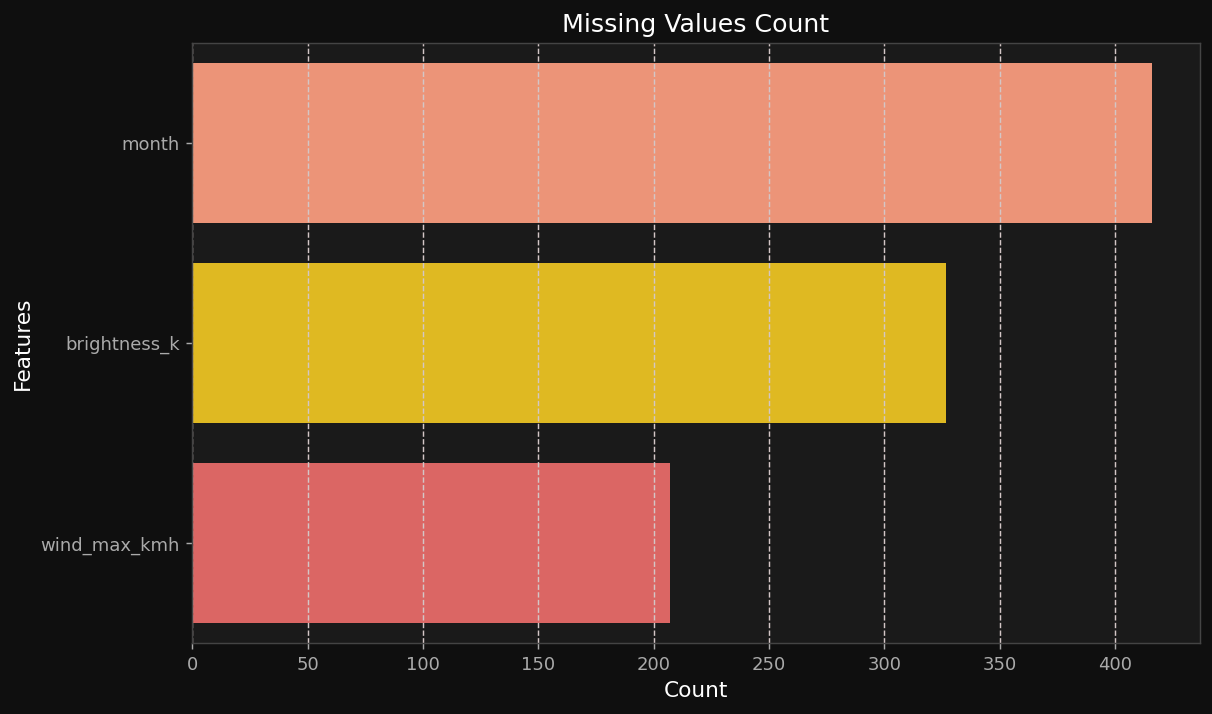

<Figure size 832x624 with 0 Axes>

In [11]:
missing_values =train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.values, y=missing_values.index, palette=['#ff8a65', '#ffcc02', '#ef5350'])
plt.title('Missing Values Count', fontsize=14, color='white')
plt.xlabel('Count', fontsize=12, color='white')
plt.ylabel('Features', fontsize=12, color='white')
plt.grid(axis='x', color="#d3c6c6", linestyle='--')
plt.style.background_color="#F0E4E400"
plt.show()
plt.tight_layout()

## 2. Checking correleation bwtween missing value features

earlier we talked about how the some features could be correlated and if they are indeed correlated then dealing with missing values could involve considering all the corelated features together and not individually, this is true for imputation or some feature selection. 

In [12]:
miss_combo = train_df[['month','brightness_k','wind_max_kmh']].isnull()
print(miss_combo.corr().round(3))

              month  brightness_k  wind_max_kmh
month         1.000        -0.019         0.019
brightness_k -0.019         1.000         0.039
wind_max_kmh  0.019         0.039         1.000


Seems like they are indeed not corelated 

## 3. Imputation rationale 

### 3.1 imputing the unreliable month feature.

for this we could simply extract the month variable from "acq_date" and replace all the values in "month" feature with the extracted value

In [13]:
# always better to work on a duplicated dataset than original,
df=train_df.copy()
# we saw that the feature "acq_date" is a Object data type and to extract the "month", "year" and "day" features from it we hav eto convert it inot a datatie vatiable.

df['acq_date'] =pd.to_datetime(df['acq_date'],errors='coerce')
# now we can just replace the whole month feature with the onth extracted from "acq_date"ArithmeticError
df['month'] =df['acq_date'].dt.month

In [14]:
df['month'].isnull().sum()

np.int64(0)

In [15]:
df['month'].dtype

dtype('int32')

In [16]:
# You know what if there are missing value it could also be true that the "year" and "day" feature could also be wrong ! so lets just replace those as welll with the extracted values from 'acq_date"

df['year']=df['acq_date'].dt.year
df['day']=df['acq_date'].dt.day



In [17]:
df.columns

Index(['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month',
       'season', 'daynight', 'region', 'country', 'fire_type', 'satellite',
       'instrument', 'brightness_k', 'confidence', 'temp_max_c',
       'wind_max_kmh', 'precip_mm', 'humidity_pct', 'fire_intensity', 'day'],
      dtype='object')

Alright from what's dpne so far we extracted new features from 'acq_date" atleast some of them , since we are going for Decision Trees and SVM, they cant really learn from complex temporal features like "axq_date" and "acq_time", so we could also extract features from "acq_time" , lets do that after we finis with imputing the missing values for rest of the features 

reference : https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/

In [18]:
df['date_dayofweek'] = df['acq_date'].dt.dayofweek
df['date_dayofyear'] = df['acq_date'].dt.dayofyear

df['acq_time_str'] = df['acq_time'].astype(str).str.zfill(4)
df['hour']   = df['acq_time_str'].str[:2].astype(int)
df['minute'] = df['acq_time_str'].str[2:].astype(int)

In [19]:
df.columns.tolist()

['latitude',
 'longitude',
 'acq_date',
 'acq_time',
 'year',
 'month',
 'season',
 'daynight',
 'region',
 'country',
 'fire_type',
 'satellite',
 'instrument',
 'brightness_k',
 'confidence',
 'temp_max_c',
 'wind_max_kmh',
 'precip_mm',
 'humidity_pct',
 'fire_intensity',
 'day',
 'date_dayofweek',
 'date_dayofyear',
 'acq_time_str',
 'hour',
 'minute']

In [20]:
# since we extracted some of the columns we can delete the original ones to avoid leaking
df.drop(columns=['acq_date','acq_time','acq_time_str'], inplace=True)

In [21]:
df.columns.tolist()

['latitude',
 'longitude',
 'year',
 'month',
 'season',
 'daynight',
 'region',
 'country',
 'fire_type',
 'satellite',
 'instrument',
 'brightness_k',
 'confidence',
 'temp_max_c',
 'wind_max_kmh',
 'precip_mm',
 'humidity_pct',
 'fire_intensity',
 'day',
 'date_dayofweek',
 'date_dayofyear',
 'hour',
 'minute']

In [22]:
df.head()

,latitude,longitude,year,month,season,daynight,region,country,fire_type,satellite,...,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity,day,date_dayofweek,date_dayofyear,hour,minute
0,-22.1967,-61.5275,2024,8,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,...,40.6,39.0,0.11,17.1,Extreme,12,0,225,18,38
1,64.2205,-53.4116,2024,7,Summer,N,North_America,Canada,Forest,Suomi-NPP,...,38.9,NaN,0.06,13.2,Low,11,3,193,4,24
2,38.6810,9.5739,2024,6,Summer,N,Mediterranean,Spain,Wildfire,AQUA,...,36.9,30.1,0.19,35.2,High,18,1,170,5,46
3,68.1959,-90.3475,2024,8,Summer,N,North_America,USA,Forest,TERRA,...,43.8,17.7,0.98,32.8,Extreme,26,0,239,22,40
4,0.6527,118.6227,2025,8,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,...,34.8,1.0,0.18,83.2,Moderate,9,5,221,23,1


## 3.2 Imputation for brightness_k

For this i think we could either use regular imputation like median mean and etc or i believe there is a strong corelation between "fire_intensity" and "brightness_k' since, if the intensity is high brightness has to be high, to prove that lets check the corelation and some plots


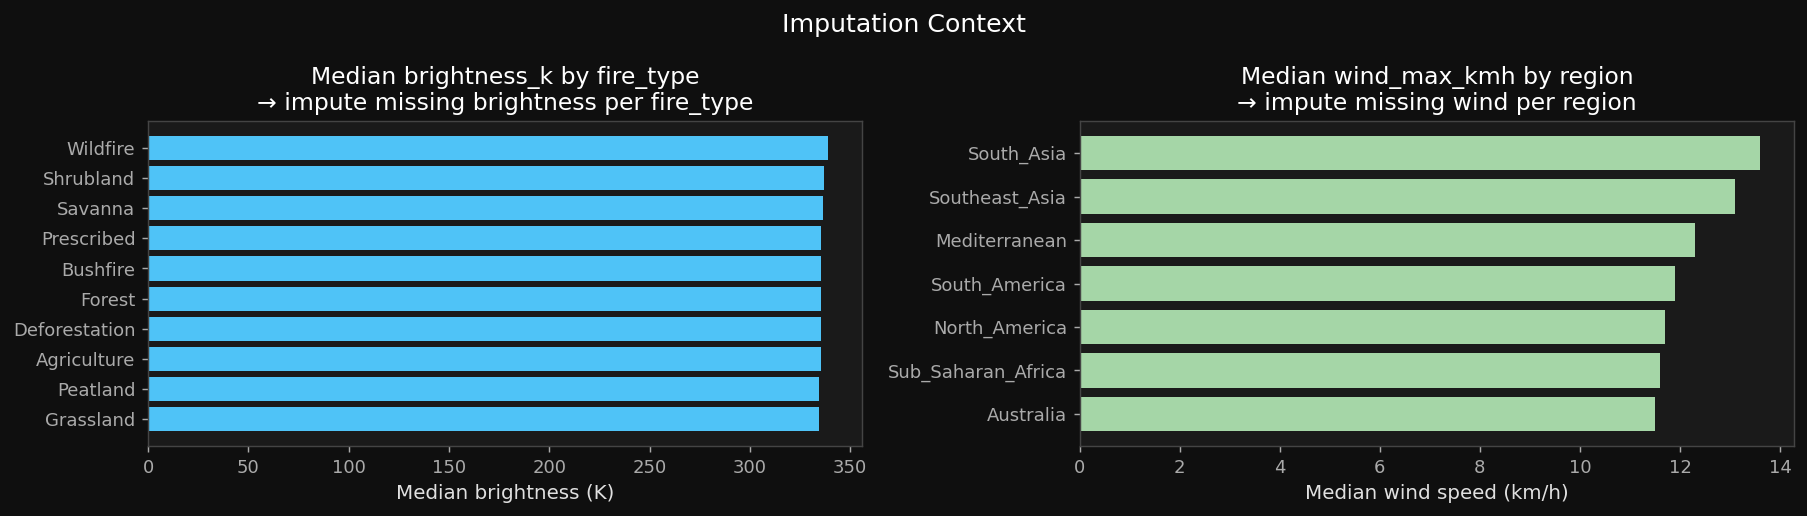

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Imputation Context', fontsize=14, color='white')

# brightness medians per fire_type
bmed = df.groupby('fire_type')['brightness_k'].median().sort_values()
axes[0].barh(bmed.index, bmed.values, color='#4fc3f7')
axes[0].set_title('Median brightness_k by fire_type\n→ impute missing brightness per fire_type')
axes[0].set_xlabel('Median brightness (K)')

# wind medians per region
wmed = df.groupby('region')['wind_max_kmh'].median().sort_values()
axes[1].barh(wmed.index, wmed.values, color='#a5d6a7')
axes[1].set_title('Median wind_max_kmh by region\n→ impute missing wind per region')
axes[1].set_xlabel('Median wind speed (km/h)')

plt.tight_layout()
plt.show()

So the main idea here is instead of using the median of the feature we group them into different "fire_types" so that we know we are categorizing thr typical range of brightness, for exaplme a house fire could be way smaller than bushfire and if we ctake common median we might end u overrshooting the brightness value of a row which has the "fire_type " feature as "housefire", TLDR, not sure if housefire exists in dataset, just an example.

in the next imputation function im just using .get(....,fallback) just in case if nomedian exists then it just takes the over all median of that particular feature instead of the group medians.

In [24]:
brightness_median = df.groupby('fire_type')['brightness_k'].median().to_dict()
wind_medians      = df.groupby('region')['wind_max_kmh'].median().to_dict()

def impute(df, brightness_median, wind_medians):
    df = df.copy()
    df['brightness_k'] = df.groupby('fire_type')['brightness_k'].transform(
        lambda x: x.fillna(brightness_median.get(x.name, df['brightness_k'].median())))
    df['brightness_k'].fillna(df['brightness_k'].median(), inplace=True)
    df['wind_max_kmh'] = df.groupby('region')['wind_max_kmh'].transform(
        lambda x: x.fillna(wind_medians.get(x.name, df['wind_max_kmh'].median())))
    df['wind_max_kmh'].fillna(df['wind_max_kmh'].median(), inplace=True)
    return df

df   = impute(df, brightness_median, wind_medians)
# test = impute(test, brightness_median, wind_medians)


## 4 Target Variable Distribution 

Let's understand how the target variable is distributed, usually we can do this in the last satge of data prep but i guess some steps are interchangable 

This is a vital step because a certain class could be highly over represented compared to others an dthat could create some training bias, as such the model would be heavily skewed, we caould simple check the distribution with some basic graphs

Text(0.5, 1.0, 'Class Proportions')

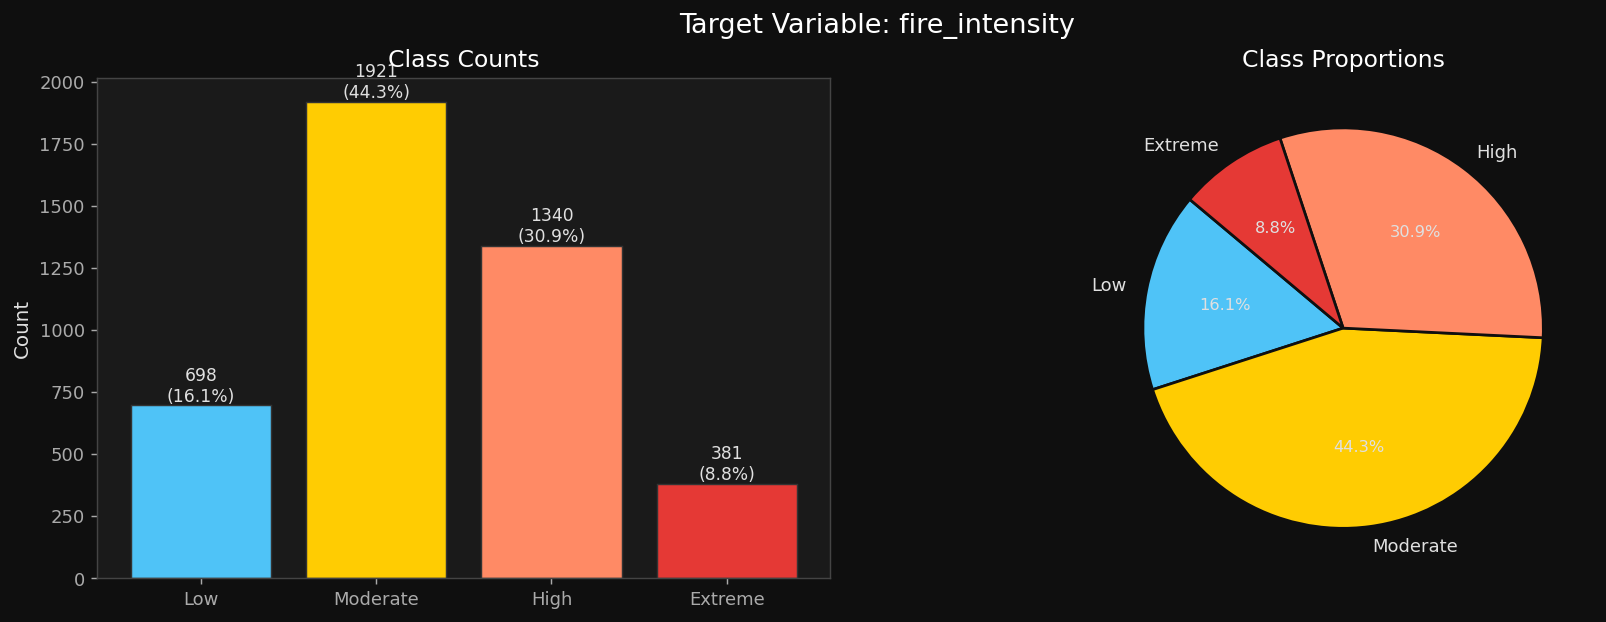

In [25]:
TARGET_ORDER = ['Low', 'Moderate', 'High', 'Extreme']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Target Variable: fire_intensity', fontsize=15, color='white')

counts  = df['fire_intensity'].value_counts().reindex(TARGET_ORDER)
pcts    = counts / len(df) * 100
colors  = [FIRE_COLORS[c] for c in TARGET_ORDER]

# A bar for a simple count and percentage 
axes[0].bar(TARGET_ORDER, counts.values, color=colors, edgecolor='#333', linewidth=0.8)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 15, f'{v}\n({p:.1f}%)', ha='center', fontsize=9.5)
axes[0].set_title('Class Counts')
axes[0].set_ylabel('Count')

# Impactful pieeee
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=TARGET_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='#0f0f0f', linewidth=1.5))
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('Class Proportions')

So Extreme fires are representing roughly 8.8% of the samples, which is underrepresentation, we cann account this during the data modelling phase. 

## 5 Neumerical feature distribution and target variable check 

We know correlation basically gives linear relationship between two variable, but often the variables are not linearly corelated, but somtimes they could be non linear, multimodel or overlapping this can be captured effectively with KDE and histograms. And also they clearly show calss seperatio , which is an important infromation we need, which would have been lost with linear correlation. 

So we are checking if these features show different patterns for different fire intensities 




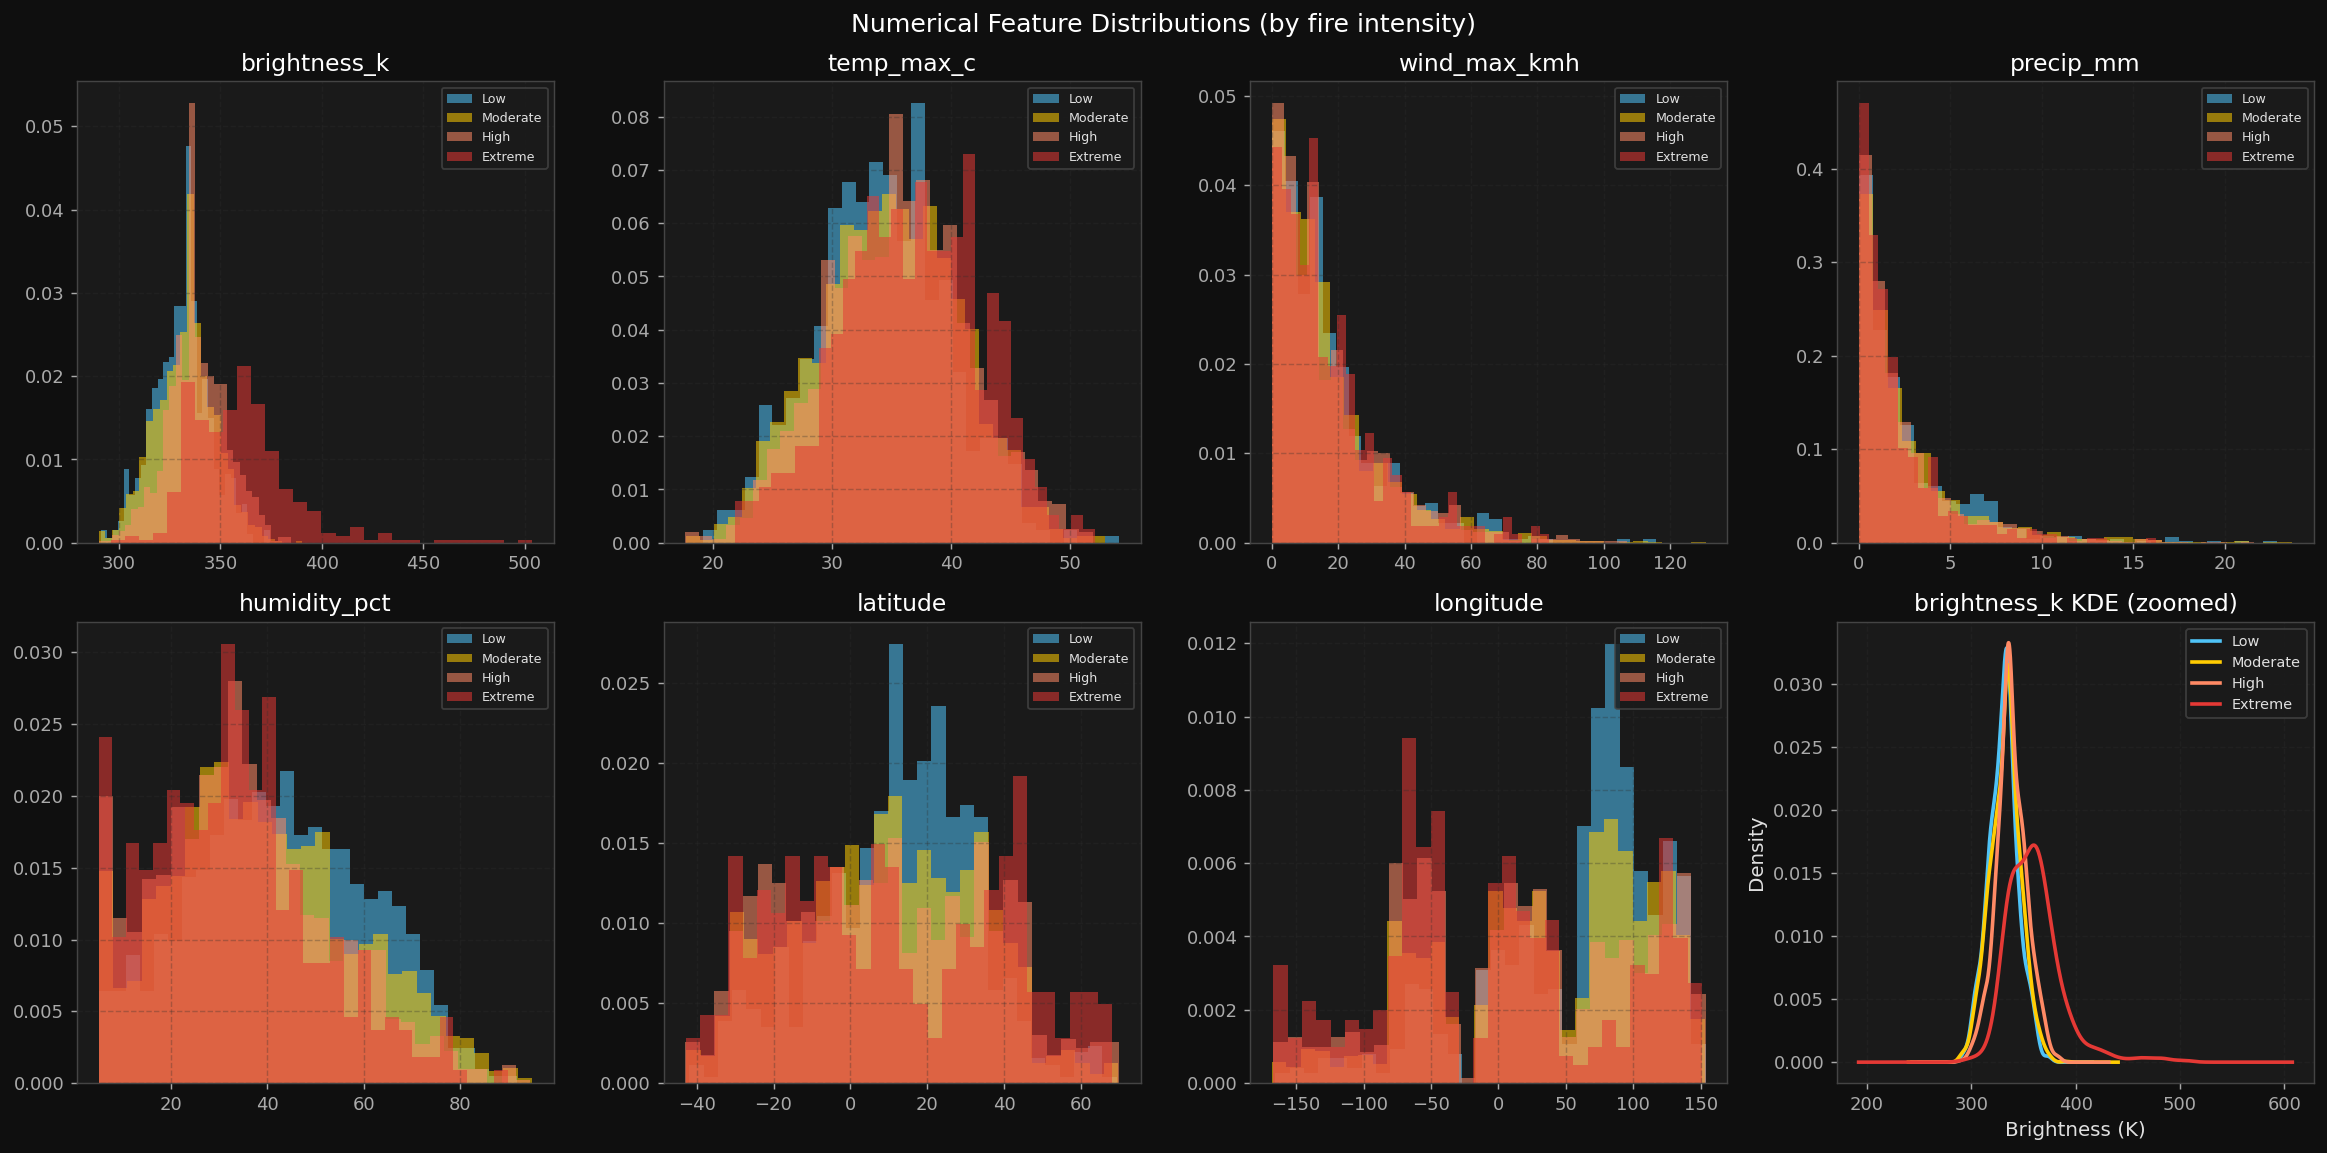

In [26]:
num_cols = ['brightness_k', 'temp_max_c', 'wind_max_kmh',
            'precip_mm', 'humidity_pct', 'latitude', 'longitude']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Numerical Feature Distributions (by fire intensity)', fontsize=14, color='white')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls in TARGET_ORDER:
        subset = df[df['fire_intensity'] == cls][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.55, color=FIRE_COLORS[cls],
                     label=cls, density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(True, alpha=0.3)

# Most discriminative panel 
ax = axes[7]
for cls in TARGET_ORDER:
    subset = df[df['fire_intensity'] == cls]['brightness_k'].dropna()
    subset.plot.kde(ax=ax, color=FIRE_COLORS[cls], label=cls, linewidth=2)
ax.set_title('brightness_k KDE (zoomed)')
ax.set_xlabel('Brightness (K)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The most intresting one here that i belive will conribute most to the training is the lattitude and longitude, you can see there are multiple peaks, which reprresents fire clusters in specific geographical regions!!!! That's a clear patttern, also seems like different intensity clusters seems to occur in different regions, that's a clear indication of an pattern, 

for example, a rainforest region could still have fires but could be low intensity, which is clearly showed by the "blue" distribution, similar case to the red distribution which is kind of extreme 

## 6 Categorical feature analysis 

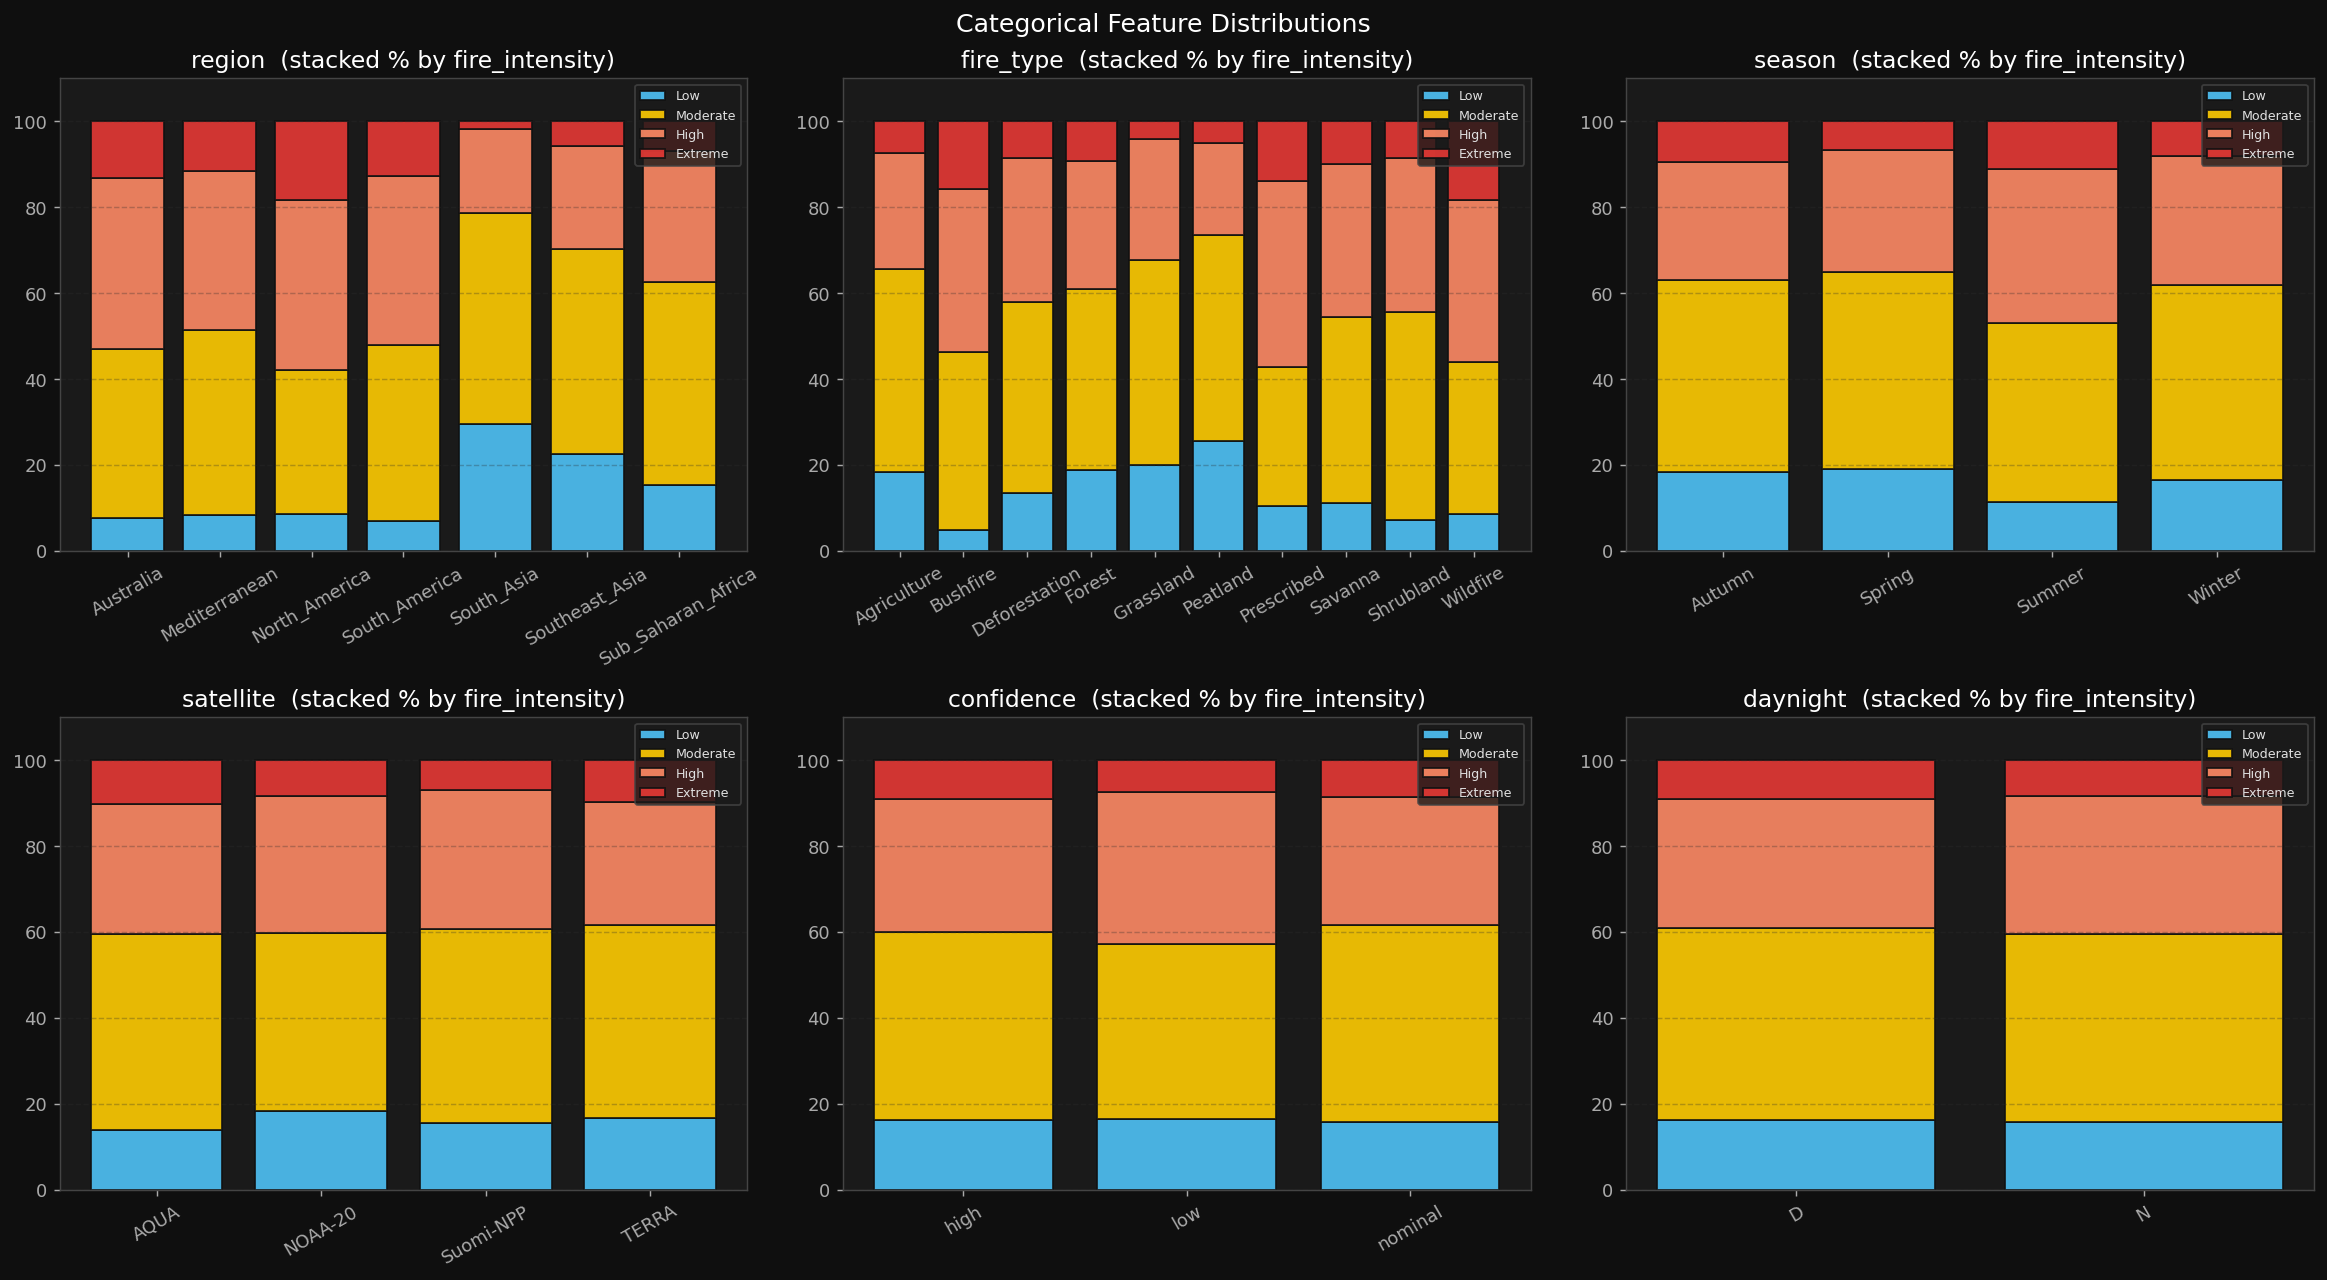

In [27]:
cat_cols = ['region', 'fire_type', 'season', 'satellite', 'confidence', 'daynight']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Categorical Feature Distributions', fontsize=14, color='white')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'fire_intensity']).size().unstack(fill_value=0)
    ct = ct.reindex(columns=TARGET_ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    bottom = np.zeros(len(ct_pct))
    for cls in TARGET_ORDER:
        axes[i].bar(ct_pct.index, ct_pct[cls], bottom=bottom,
                    color=FIRE_COLORS[cls], label=cls, alpha=0.9, edgecolor='#111')
        bottom += ct_pct[cls].values

    axes[i].set_title(f'{col}  (stacked % by fire_intensity)')
    axes[i].set_ylim(0, 110)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

This graph basically tells "daynight " is not really doing what its expected to do, we would think the intensity is low during night but the feature isnt really showing that so i believe we could dropit, also all the "Satellites" are doing the same job so it's an obvious drop.

the main dilema is with the "confidence", i believe there could be some data leakeage between strong and weak categoreis but not sure, because "confidence" is basically derived from brightness higher brightness flames are easily detected but that dosent mean lower brightness flames are not easily detected, it's just a confusing feature for me 

We could also check fire distribution index by country this gives us a geographical indication of which regions bight be more prone to fire accidents or if there is a fire incident, how severe it could be, 

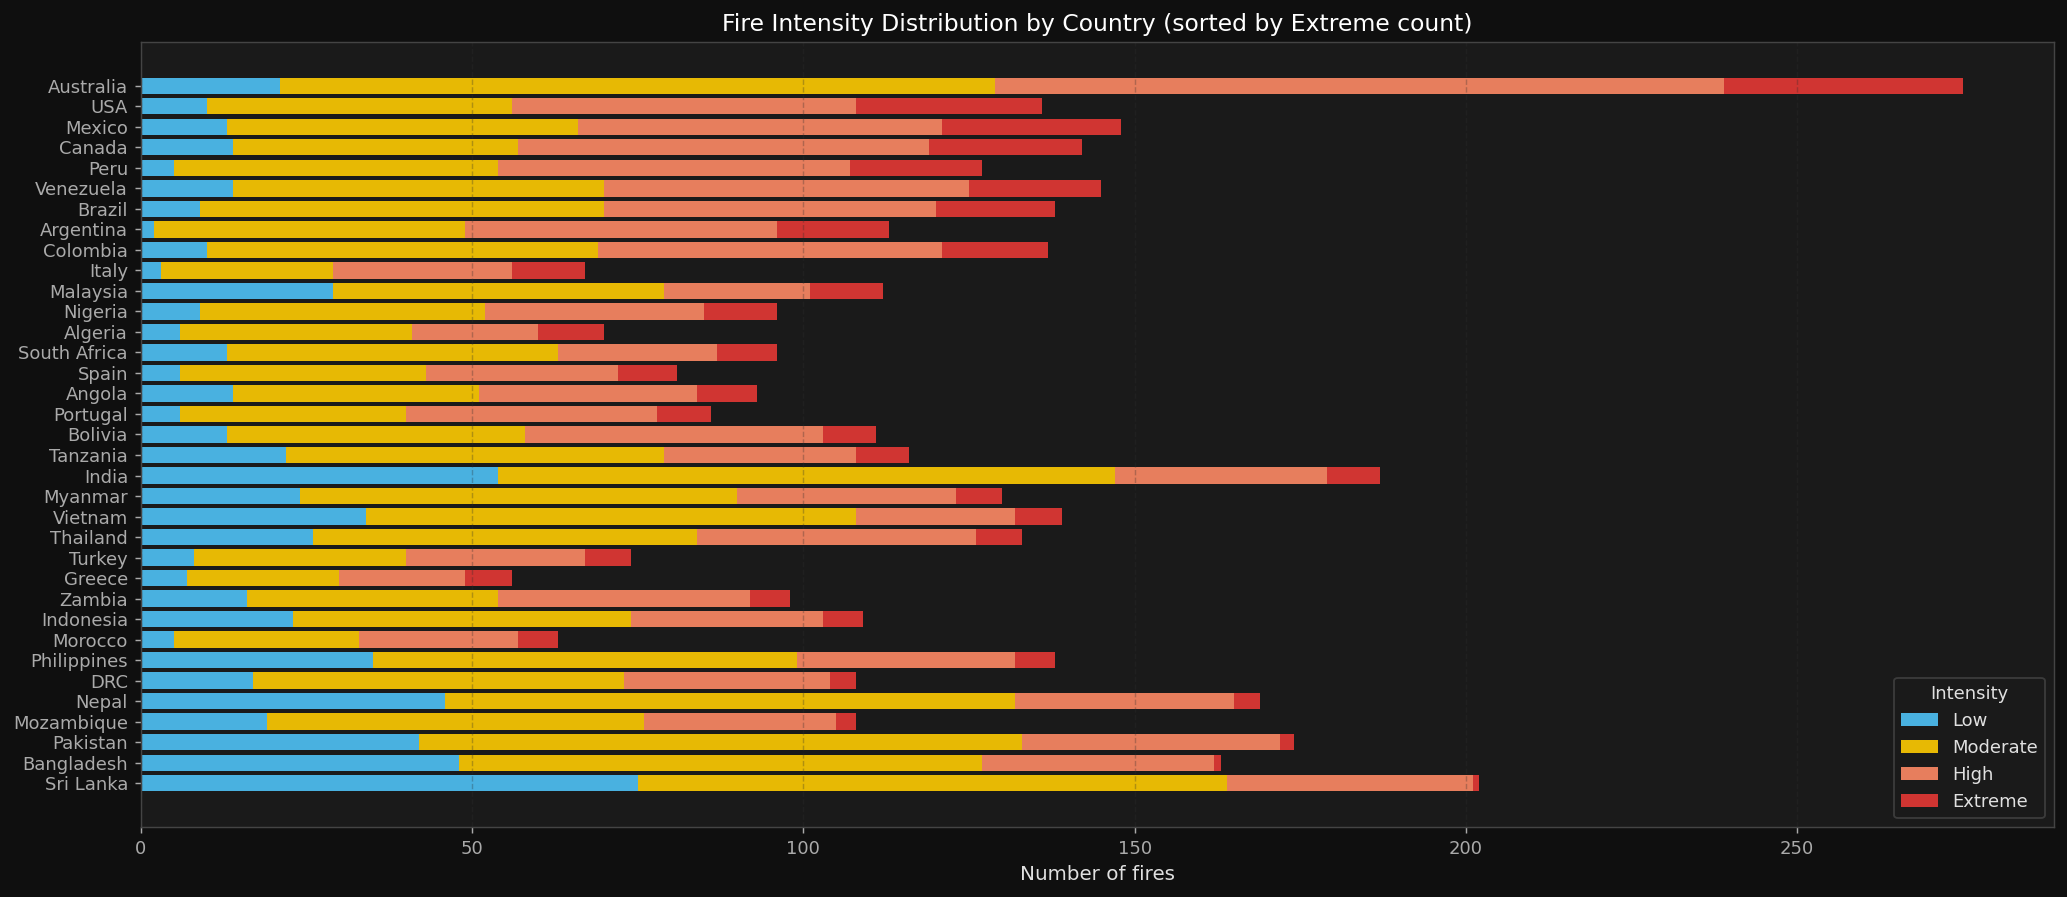

In [28]:
fig, ax = plt.subplots(figsize=(16, 7))
ct = df.groupby(['country', 'fire_intensity']).size().unstack(fill_value=0)
ct = ct.reindex(columns=TARGET_ORDER, fill_value=0)

# Sort by Extreme fire count
ct = ct.sort_values('Extreme', ascending=True)
bottom = np.zeros(len(ct))
for cls in TARGET_ORDER:
    ax.barh(ct.index, ct[cls], left=bottom, color=FIRE_COLORS[cls], label=cls, alpha=0.9)
    bottom += ct[cls].values

ax.set_title('Fire Intensity Distribution by Country (sorted by Extreme count)', fontsize=13)
ax.set_xlabel('Number of fires')
ax.legend(title='Intensity')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### 7 feature target relationships
before building out model qe have to know if our features are really signaling a growth with the target, if there is any data leakeage, classify weak and storong features etc., basically checking if the particular feature knows something about the target or not.

we know the target variable is ofcourse the "fire_intensity" lets check using box plot and violin plot againt all the features

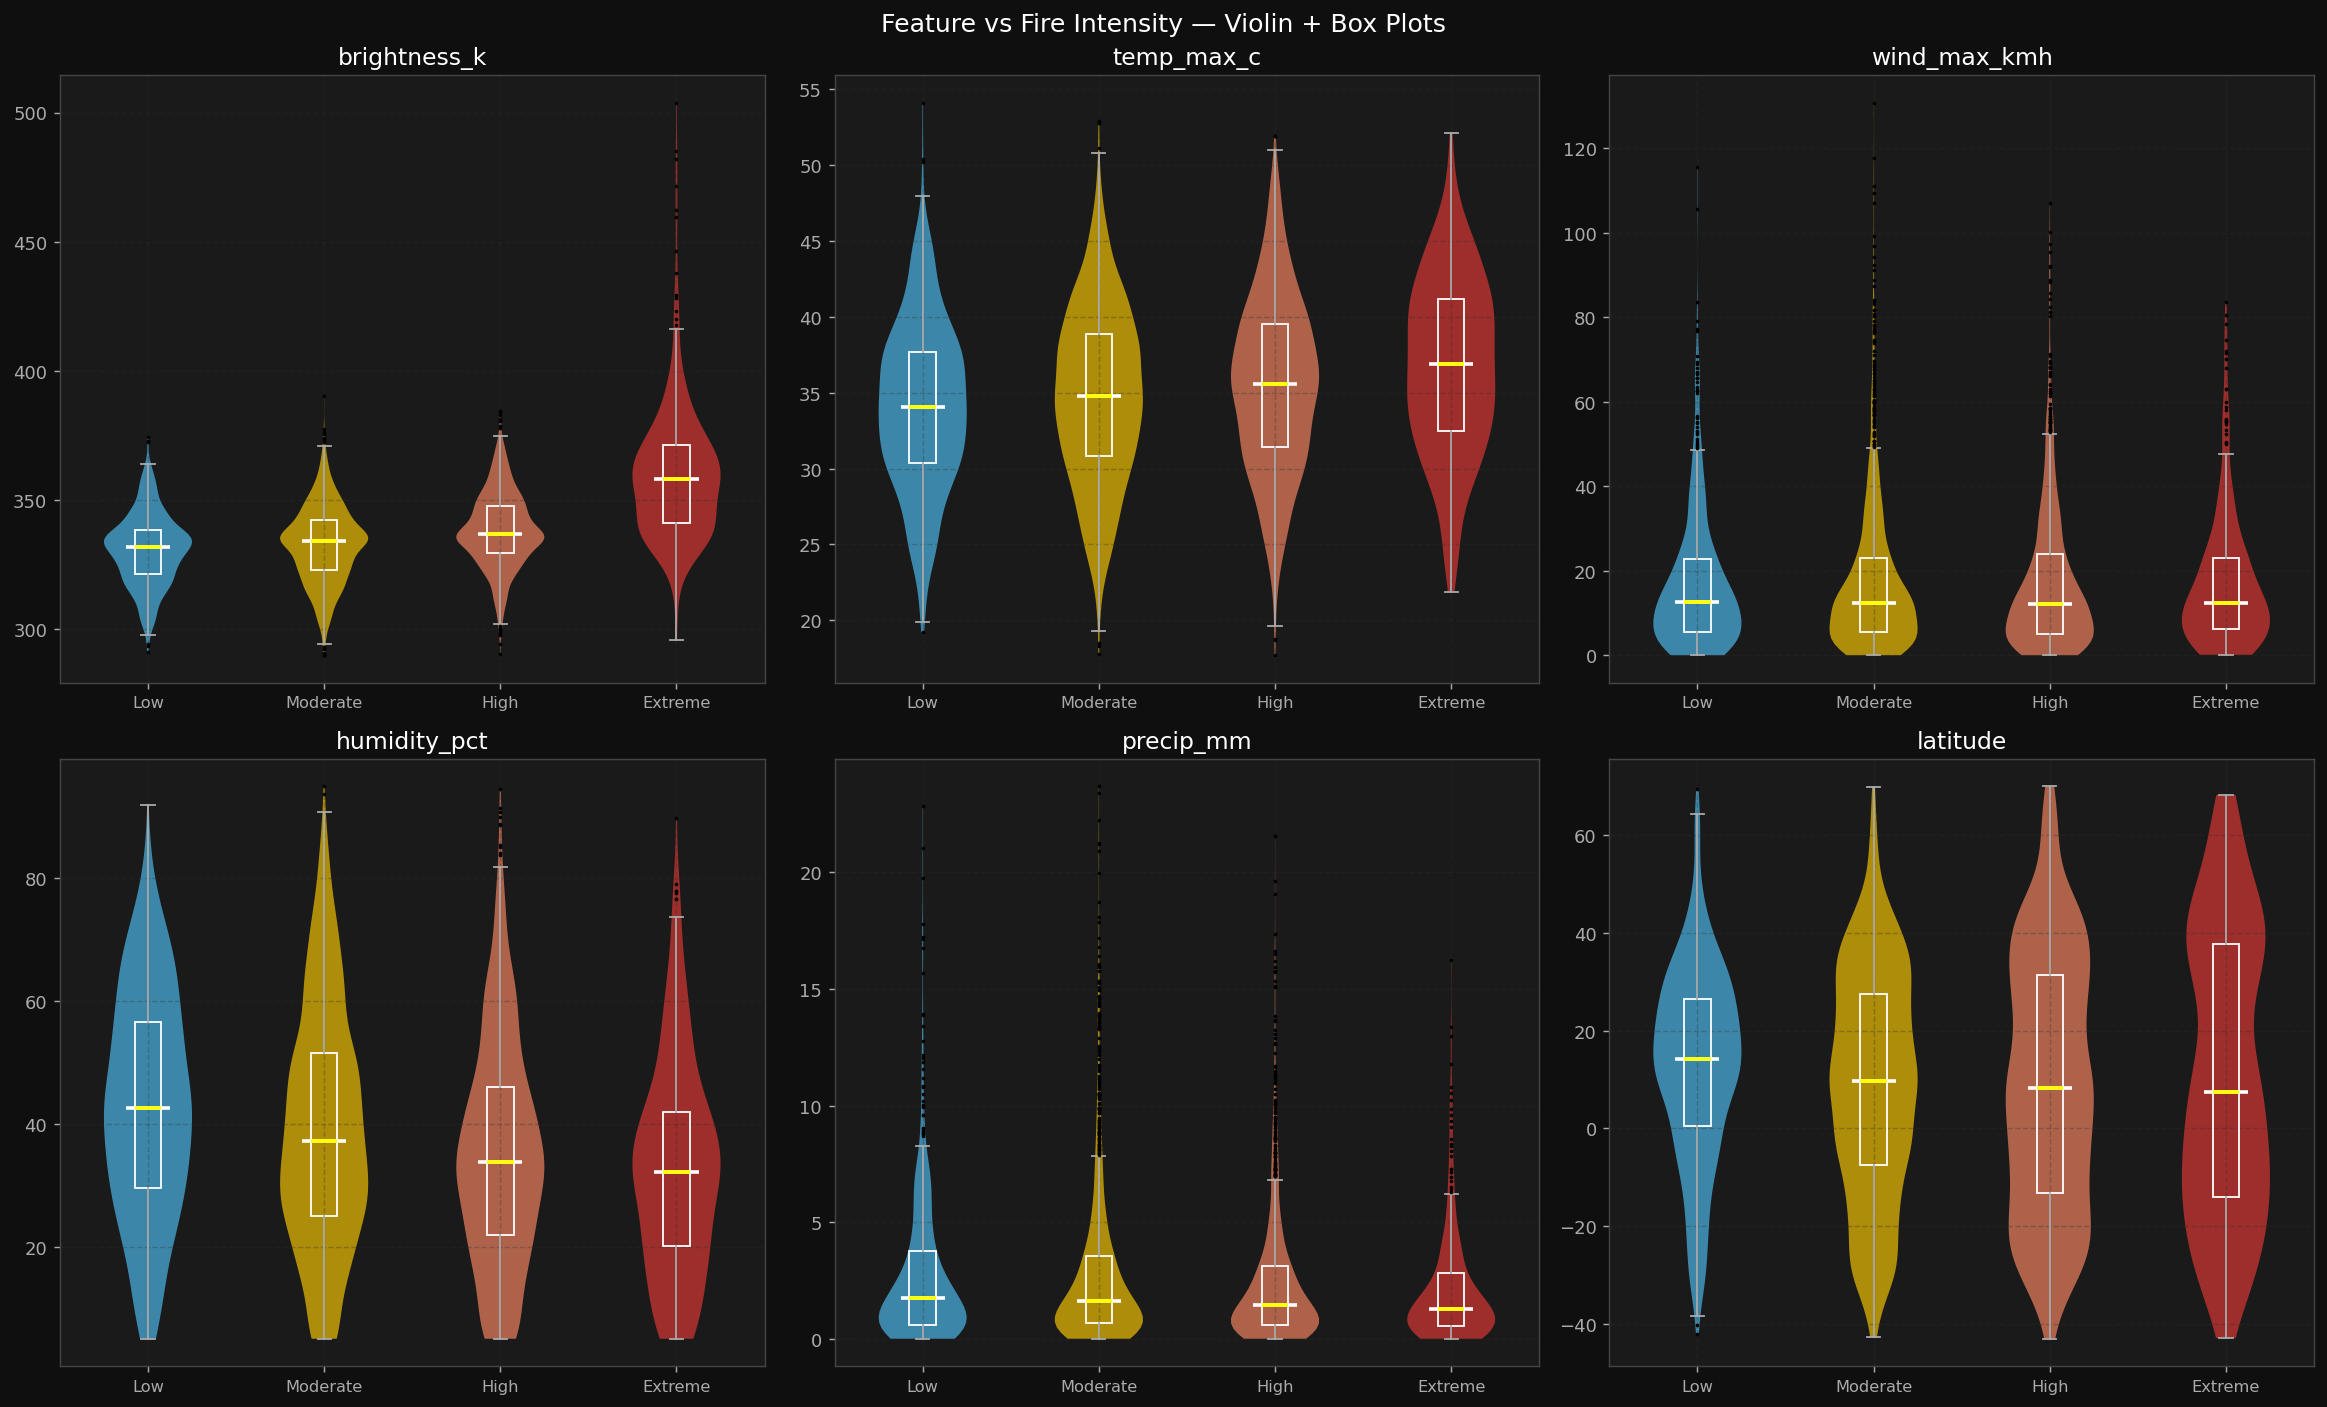

In [29]:

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Feature vs Fire Intensity — Violin + Box Plots', fontsize=14, color='white')
axes = axes.flatten()

plot_cols = ['brightness_k', 'temp_max_c', 'wind_max_kmh',
             'humidity_pct', 'precip_mm', 'latitude']
palette_map = {cls: FIRE_COLORS[cls] for cls in TARGET_ORDER}

for i, col in enumerate(plot_cols):
    data_by_class = [df[df['fire_intensity']==cls][col].dropna().values for cls in TARGET_ORDER]

    vp = axes[i].violinplot(data_by_class, positions=range(4),
                             showmedians=True, showextrema=False)
    for j, body in enumerate(vp['bodies']):
        body.set_facecolor(list(FIRE_COLORS.values())[j])
        body.set_alpha(0.65)
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(2)

    bp = axes[i].boxplot(data_by_class, positions=range(4),
                          widths=0.15, patch_artist=True,
                          boxprops=dict(facecolor='none', color='white'),
                          whiskerprops=dict(color='#aaa'),
                          capprops=dict(color='#aaa'),
                          medianprops=dict(color='yellow', linewidth=2),
                          flierprops=dict(marker='.', color='#666', markersize=2))

    axes[i].set_xticks(range(4))
    axes[i].set_xticklabels(TARGET_ORDER, fontsize=9)
    axes[i].set_title(col)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


* Lattitude is bascially giving the geographical ontext, im not bery sure this is the right plot for lattitude but it gives a good idea about the spread, like moderate seems to happen in mid lattitudes like 30 degress.
* percip_mm tells absolutely nothing, or just says fires happen in dry conditions as no rain regardless of intensity.
* this is kind of perception but still tells a story, lower fires in higher humid areas and higher fires in lower humid areas (33 degrees, maybe ??) and those violins shifting left shows clear correlation.
* for wind though the difference seems to be in the extremes as there is a lot of tail regardless of intensity, 
* temp+max, no idea, plots seems to overlapa but is kind of similar to humidity, maybe a weak indicator
* brightness_k, we have already established a relation, direcrtly corelated 

### 8 Multicolinearity 
just like in the previous assignment im gonna use Variance inflation factor and corelation matrix to flag multicolinearity, as redudancy and instability could be caused by multicolinearity 

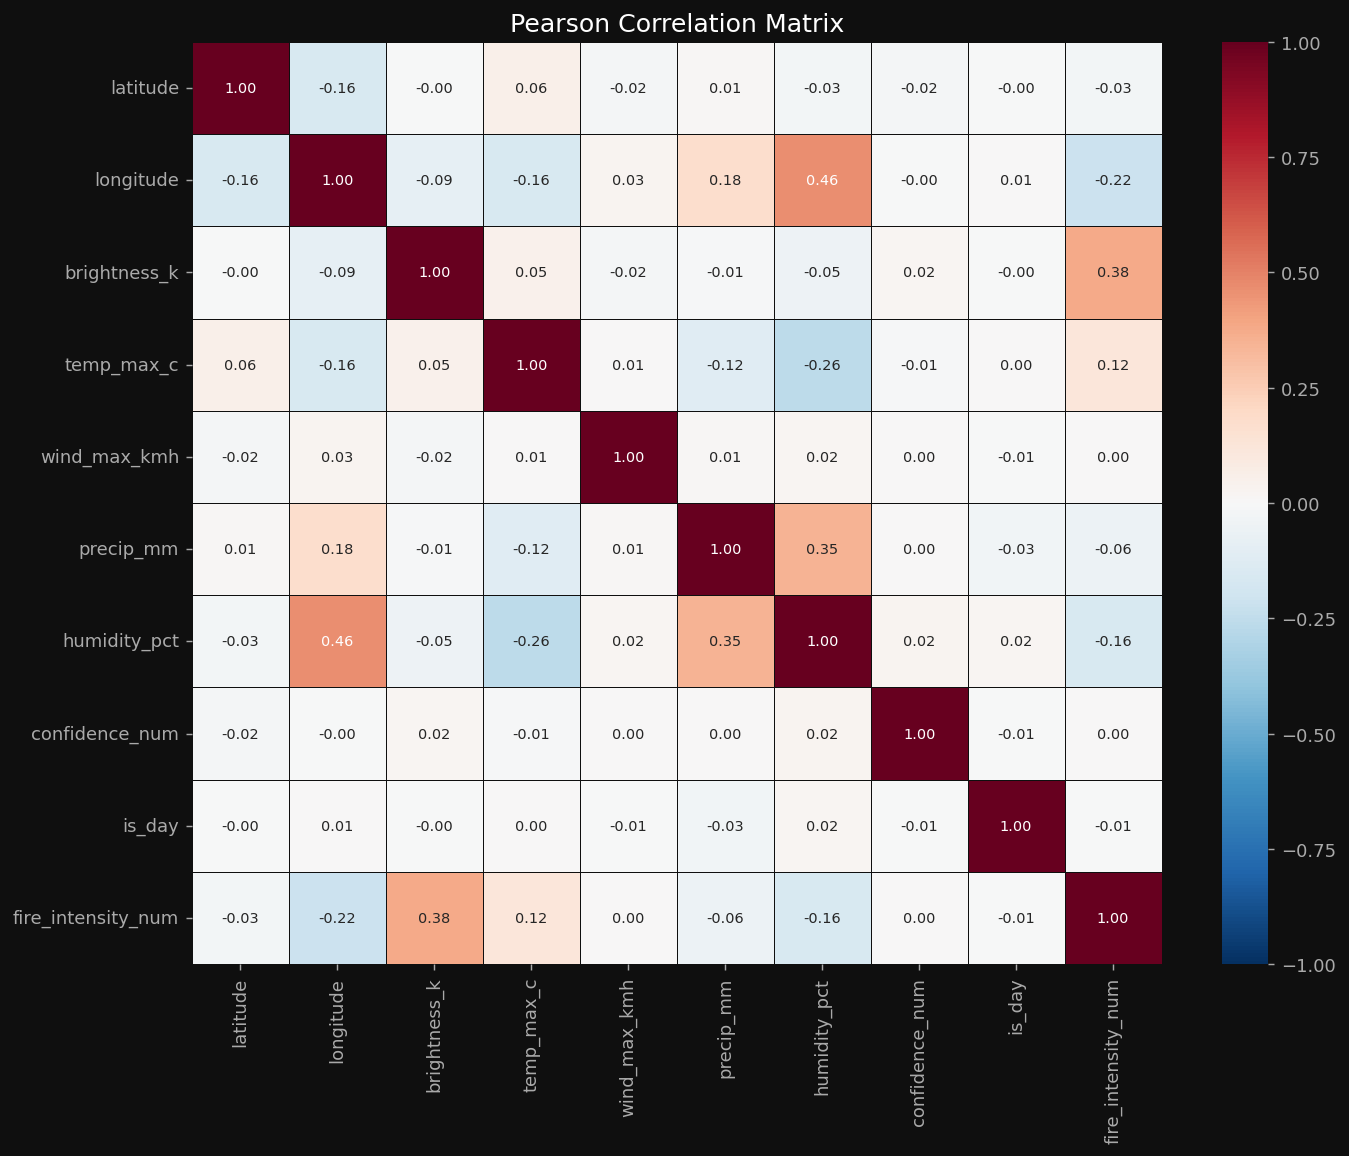

In [30]:
df_corr = df.copy()
df_corr['fire_intensity_num'] = df_corr['fire_intensity'].map(
    {v: i for i, v in enumerate(TARGET_ORDER)})
df_corr['confidence_num'] = df_corr['confidence'].map({'low':0,'nominal':1,'high':2})
df_corr['is_day'] = (df_corr['daynight'] == 'D').astype(int)

num_for_corr = ['latitude','longitude','brightness_k','temp_max_c',
                'wind_max_kmh','precip_mm','humidity_pct',
                'confidence_num','is_day','fire_intensity_num']

corr_matrix = df_corr[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#0f0f0f',
            annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

That's a much better correlation map than i expected, everything seems to be normal or almost equally corelated nothing too strong, but we could certainly remove some 0.00 correlated features lik wind_max_kmh, this is exactly what we thought from the previous violin plots, tldr not im not very good at understanding box plots.

### 9 Temporal and Geo spatial opverview

i feel like thisis the most important analysis we have to do, like depending on the area we can easily say if the fire intensity is going to be extrenme or not, for example areas near arid climates like sub saharan will most definetly have huge flames as there is absolutely no humidity, so yes let's find out.

We extract signals from `acq_date` and `acq_time` and examine fire intensity patterns across months, seasons, and hours

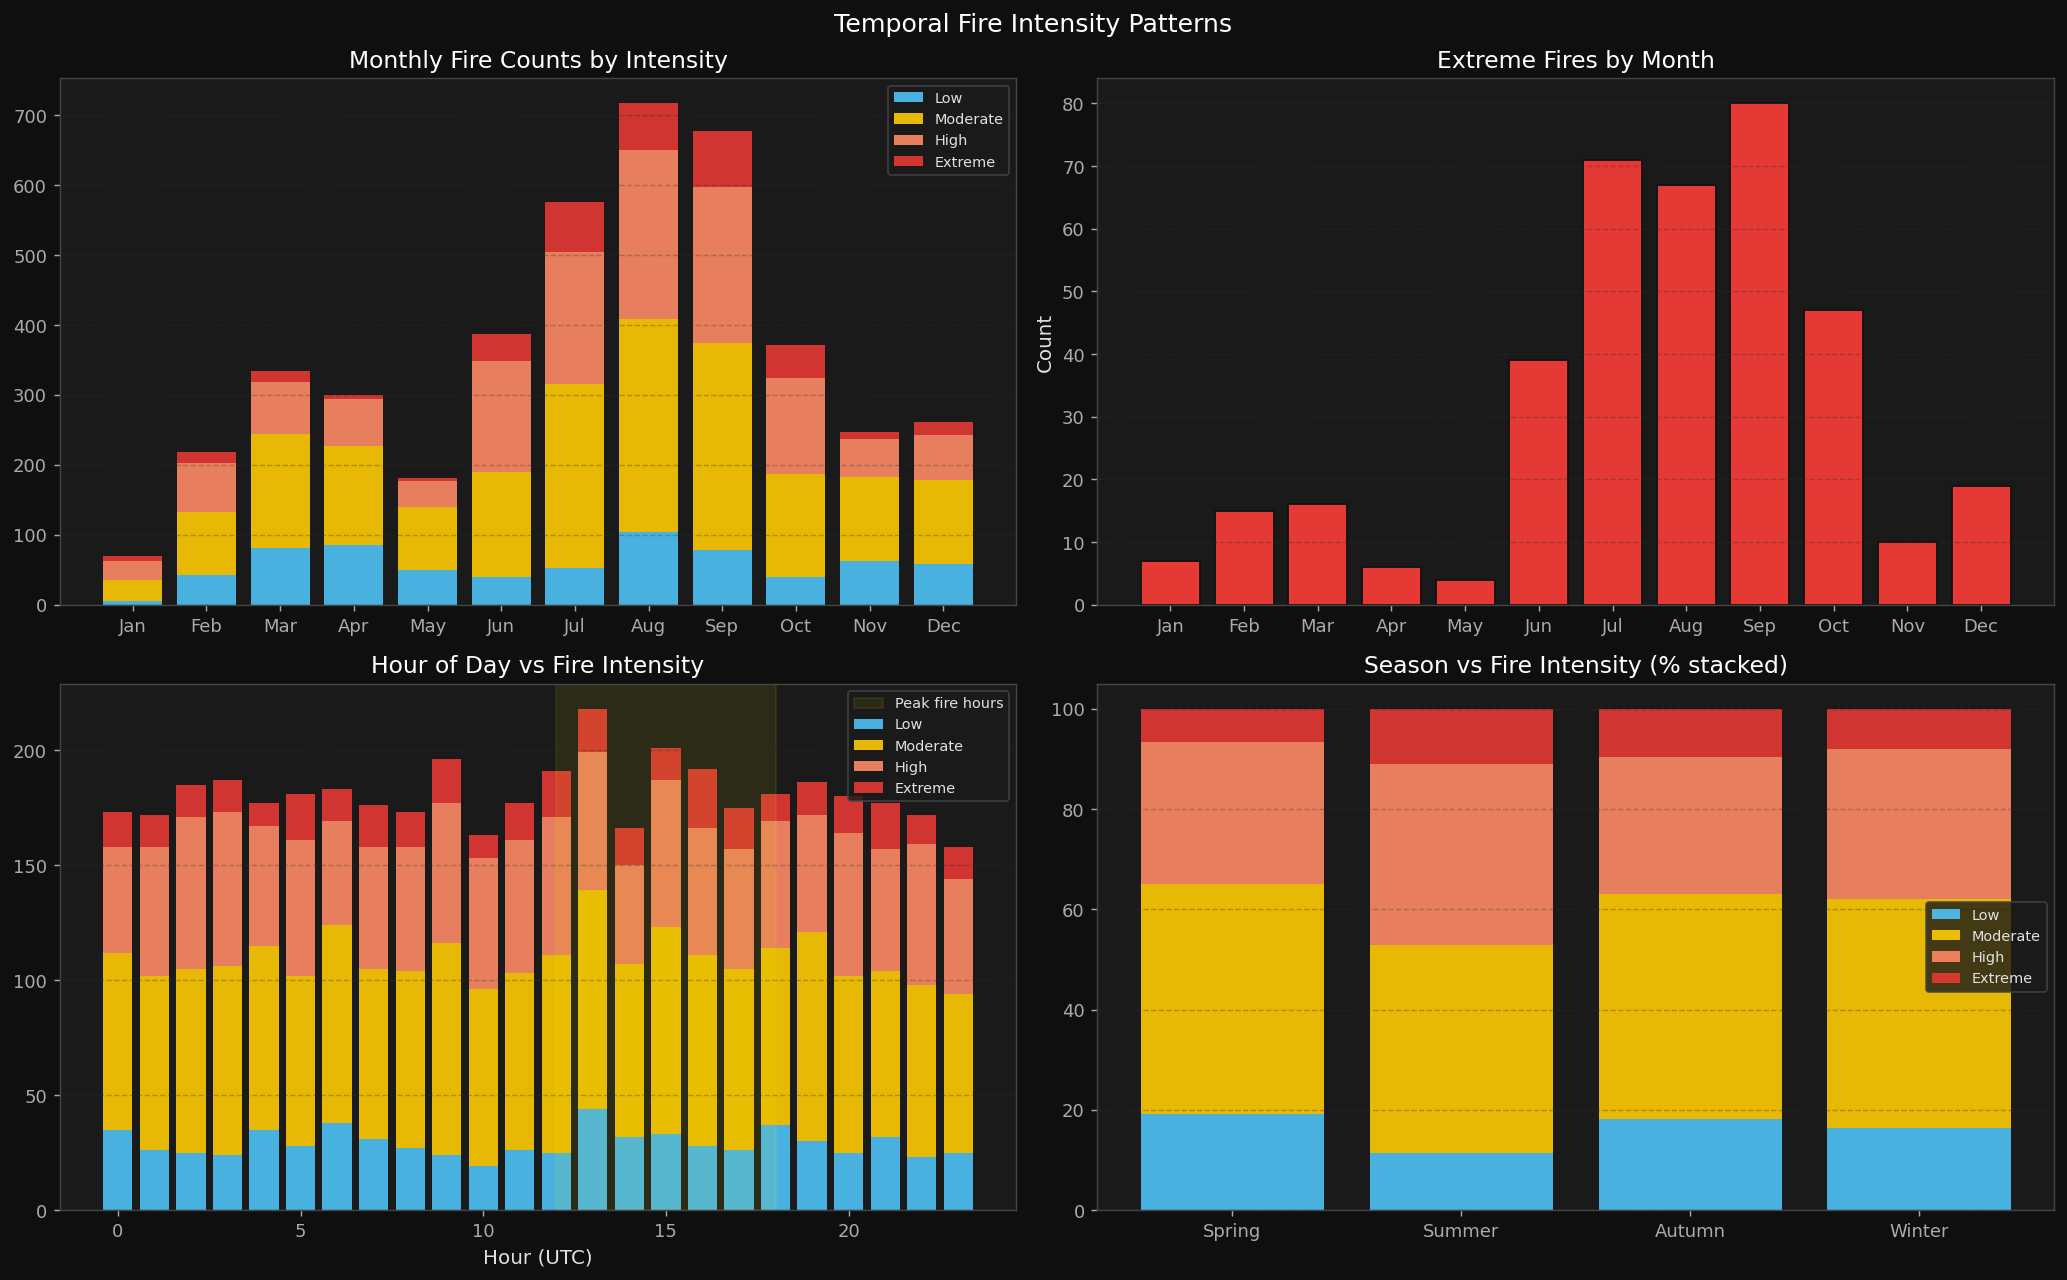

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Fire Intensity Patterns', fontsize=14, color='white')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
# forgot i hav already engineerd acq_date into month, year and day features, maybe i should have done feature engineering later 
# month but stacked  by intensity 
ct_month = df.groupby(['month','fire_intensity']).size().unstack(fill_value=0).reindex(columns=TARGET_ORDER)
bottom = np.zeros(12)
for cls in TARGET_ORDER:
    vals = ct_month.reindex(range(1,13), fill_value=0)[cls].values
    axes[0,0].bar(range(1,13), vals, bottom=bottom, color=FIRE_COLORS[cls], label=cls, alpha=0.9)
    bottom += vals
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(month_names)
axes[0,0].set_title('Monthly Fire Counts by Intensity')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(axis='y', alpha=0.3)

# month
extreme_monthly = df[df['fire_intensity']=='Extreme']['month'].value_counts().reindex(range(1,13), fill_value=0)
axes[0,1].bar(range(1,13), extreme_monthly.values, color='#e53935', edgecolor='#111')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_names)
axes[0,1].set_title('Extreme Fires by Month')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(axis='y', alpha=0.3)

# hour of the day
ct_hour = df.groupby(['hour','fire_intensity']).size().unstack(fill_value=0).reindex(columns=TARGET_ORDER)
bottom = np.zeros(24)
for cls in TARGET_ORDER:
    vals = ct_hour.reindex(range(24), fill_value=0)[cls].values
    axes[1,0].bar(range(24), vals, bottom=bottom, color=FIRE_COLORS[cls], label=cls, alpha=0.9)
    bottom += vals
axes[1,0].axvspan(12, 18, alpha=0.08, color='yellow', label='Peak fire hours')
axes[1,0].set_title('Hour of Day vs Fire Intensity')
axes[1,0].set_xlabel('Hour (UTC)')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(axis='y', alpha=0.3)


ct_season = df.groupby(['season','fire_intensity']).size().unstack(fill_value=0).reindex(columns=TARGET_ORDER)
season_order = ['Spring','Summer','Autumn','Winter']
ct_pct = ct_season.reindex(season_order).div(ct_season.reindex(season_order).sum(axis=1), axis=0)*100
bottom = np.zeros(4)
for cls in TARGET_ORDER:
    axes[1,1].bar(season_order, ct_pct[cls], bottom=bottom, color=FIRE_COLORS[cls], label=cls, alpha=0.9)
    bottom += ct_pct[cls].values
axes[1,1].set_title('Season vs Fire Intensity (% stacked)')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
df.columns

Index(['latitude', 'longitude', 'year', 'month', 'season', 'daynight',
       'region', 'country', 'fire_type', 'satellite', 'instrument',
       'brightness_k', 'confidence', 'temp_max_c', 'wind_max_kmh', 'precip_mm',
       'humidity_pct', 'fire_intensity', 'day', 'date_dayofweek',
       'date_dayofyear', 'hour', 'minute'],
      dtype='object')

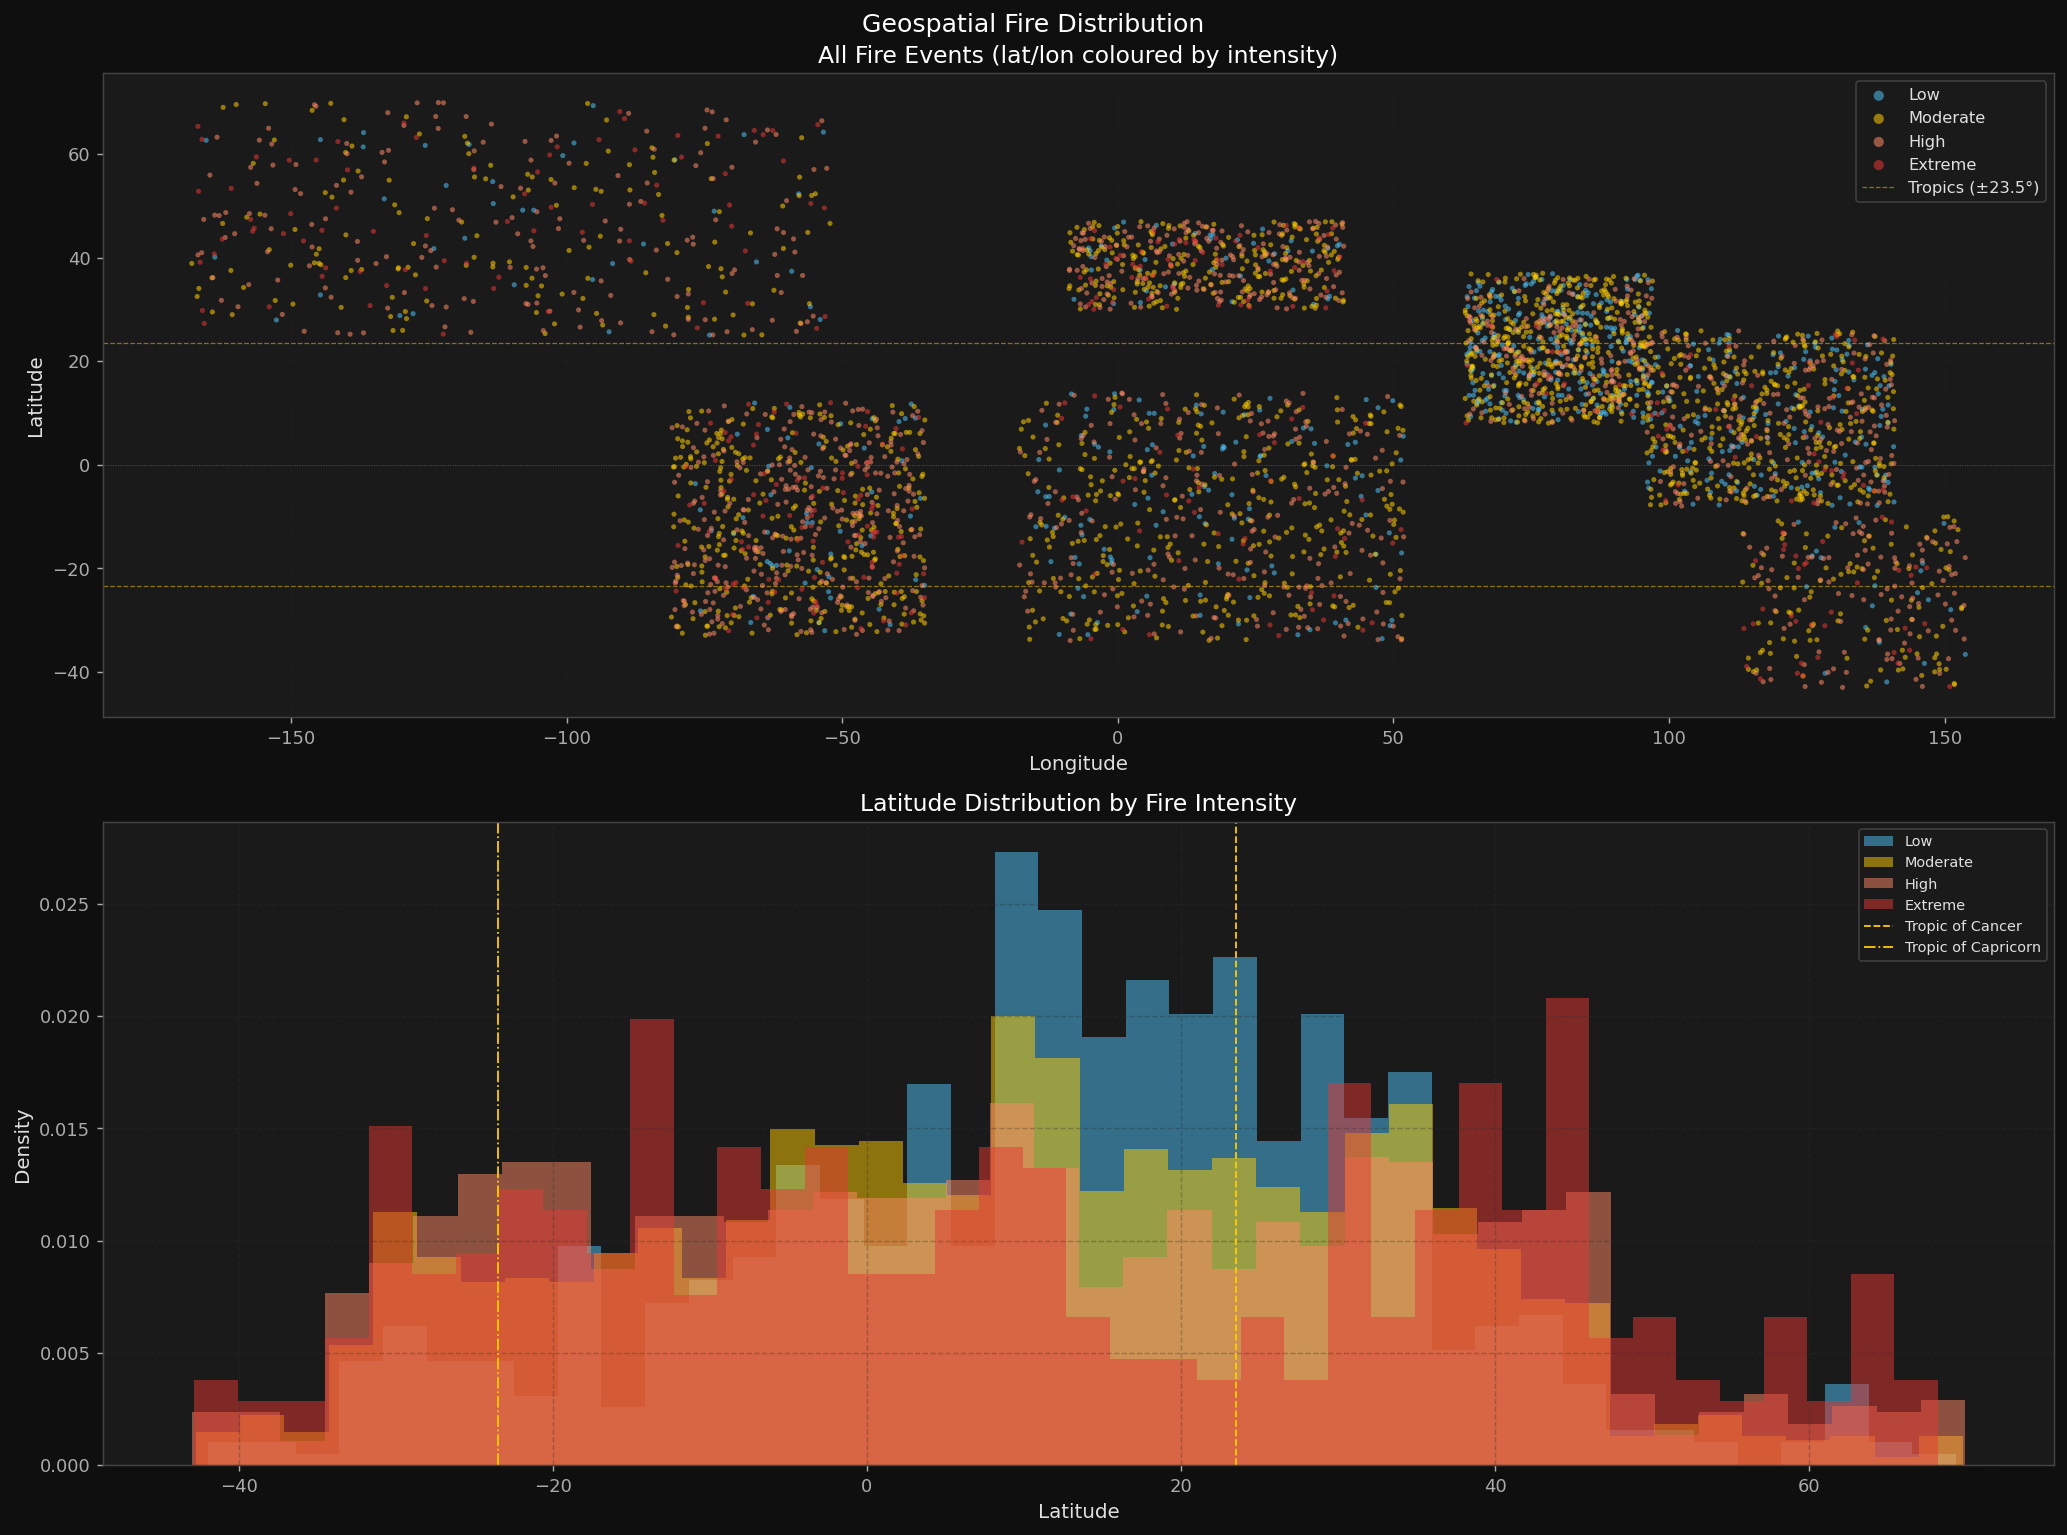

In [ ]:
# this block is for geospatial, the most intresting one by far.
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Geospatial Fire Distribution', fontsize=14, color='white')
for cls in TARGET_ORDER:
    sub = df[df['fire_intensity'] == cls]
    axes[0].scatter(sub['longitude'], sub['latitude'],
                    c=FIRE_COLORS[cls], s=8, alpha=0.55,
                    label=cls, edgecolors='none', zorder=3)
axes[0].axhline(23.5, color='#ffcc02', linestyle='--', linewidth=0.7, alpha=0.5, label='Tropics (±23.5°)')
axes[0].axhline(-23.5, color='#ffcc02', linestyle='--', linewidth=0.7, alpha=0.5)
axes[0].axhline(0, color='#aaa', linestyle=':', linewidth=0.5, alpha=0.4)
axes[0].set_title('All Fire Events (lat/lon coloured by intensity)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(fontsize=9, markerscale=2)
axes[0].grid(True, alpha=0.2)


for cls in TARGET_ORDER:
    vals = df[df['fire_intensity']==cls]['latitude'].dropna()
    axes[1].hist(vals, bins=40, alpha=0.5, density=True, color=FIRE_COLORS[cls], label=cls)
axes[1].axvline(23.5,  color='#ffcc02', linestyle='--', linewidth=1, label='Tropic of Cancer')
axes[1].axvline(-23.5, color='#ffcc02', linestyle='-.', linewidth=1, label='Tropic of Capricorn')
axes[1].set_title('Latitude Distribution by Fire Intensity')
axes[1].set_xlabel('Latitude')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

-Used claude to understand this, too much clutter

* so Australia is hot, extreme and moderate seems to be common occurance, (lon -150 to lat 10 to 45)
* other key observation is most of the high intensity sites sit between +- 23.5 degrees, wonder if its the equator or tropical ??

* extreme is broad flat base at -45 to 60 degree lon, southern australia as per google. 
* the tropics are represented by dashed line and low and moderate intensities are located, this directly contradicts with what i though from previous observation that high intensities sit at +-23.5 degress which could be tropical, so +-23.4 is definetly not tropical, might have to google it 



In [43]:
# geo clustering and feature engineering 
df['lat_lon_interaction'] = df['latitude'] * df['longitude']

df['abs_latitude'] = df['latitude'].abs()

df['is_southern'] = (df['latitude'] < 0).astype(int)
df['is_eastern']  = (df['longitude'] > 0).astype(int)

# ── Tropical zone flag (within ±23.5°) ──
df['in_tropics'] = (df['latitude'].abs() <= 23.5).astype(int)
df['lat_zone'] = pd.cut(
    df['latitude'],
    bins=[-90, -45, -23.5, 0, 23.5, 45, 90],
    labels=['Southern_Extratropical', 'Southern_Subtropical',
            'Southern_Tropical', 'Northern_Tropical',
            'Northern_Subtropical', 'Northern_Extratropical']
)

from sklearn.cluster import KMeans

coords = df[['latitude', 'longitude']]
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df['geo_cluster'] = kmeans.fit_predict(coords)

### 10 Outlier detection 

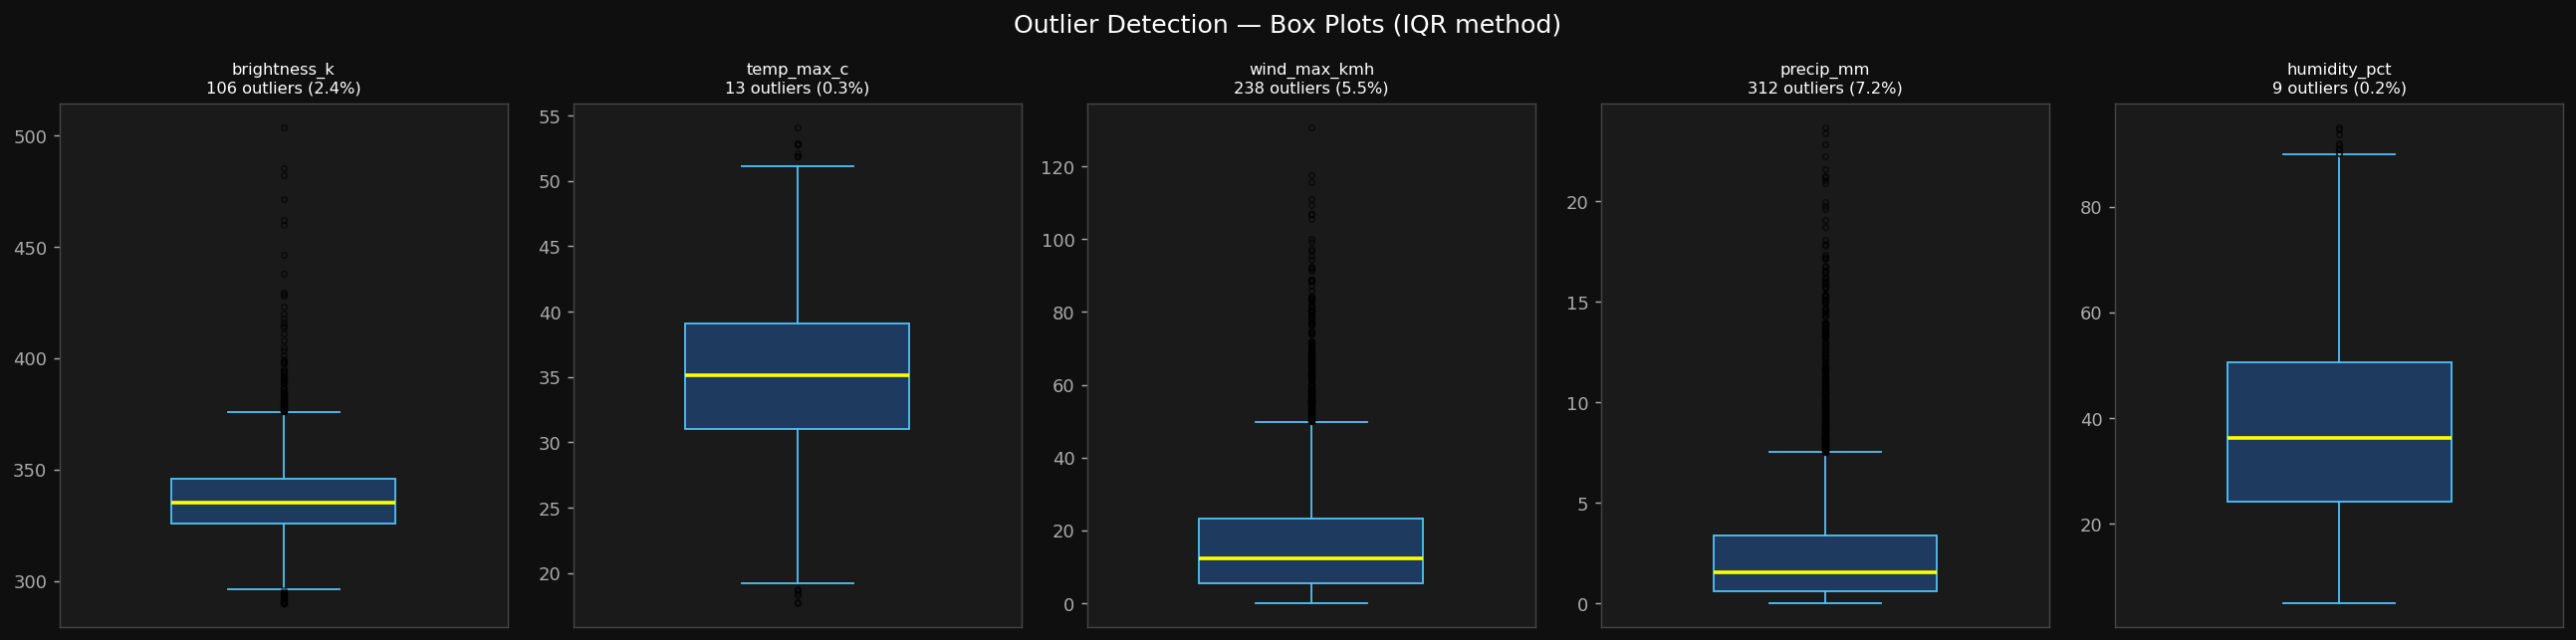

     feature  n_outliers  pct  lower_fence  upper_fence
brightness_k         106 2.44       296.10       375.70
  temp_max_c          13 0.30        18.81        51.31
wind_max_kmh         238 5.48       -21.30        49.90
   precip_mm         312 7.19        -3.56         7.52
humidity_pct           9 0.21       -15.25        89.95


In [45]:
outlier_cols = ['brightness_k', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Outlier Detection — Box Plots (IQR method)', fontsize=14, color='white')

outlier_summary = []
for i, col in enumerate(outlier_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((data < lo) | (data > hi)).sum()
    pct_out = n_out / len(data) * 100
    outlier_summary.append({'feature': col, 'n_outliers': n_out,
                             'pct': round(pct_out,2), 'lower_fence': round(lo,2),
                             'upper_fence': round(hi,2)})

    bp = axes[i].boxplot(data, patch_artist=True, vert=True, widths=0.5,
                          boxprops=dict(facecolor='#1e3a5f', color='#4fc3f7'),
                          whiskerprops=dict(color='#4fc3f7'),
                          capprops=dict(color='#4fc3f7'),
                          medianprops=dict(color='yellow', linewidth=2),
                          flierprops=dict(marker='o', color='#ef5350',
                                          markersize=3, alpha=0.5))
    axes[i].set_title(f'{col}\n{n_out} outliers ({pct_out:.1f}%)', fontsize=9)
    axes[i].set_xticks([])

plt.tight_layout()
plt.show()
print(pd.DataFrame(outlier_summary).to_string(index=False))


 Iused claude to use change the test data set and make it similar to the train dataset, as i did some feature engineering on the go before completing the complete data prep and understanding and it was so clustersome to go through 

In [47]:
#Thiswhole block is for preparing the test set, given completely by Claude Sonnet. 
# Reference: https://claude.ai/share/d92ceff9-7b11-449a-b093-8d5c5350ab8d
# 
#  1. Load test
test_df = pd.read_csv('wildfire_cls_test_features.csv')
test = test_df.copy()

# 2. Date/time engineering
test['acq_date']      = pd.to_datetime(test['acq_date'], errors='coerce')
test['month']         = test['acq_date'].dt.month
test['year']          = test['acq_date'].dt.year
test['day']           = test['acq_date'].dt.day
test['date_dayofweek']= test['acq_date'].dt.dayofweek
test['date_dayofyear']= test['acq_date'].dt.dayofyear

test['acq_time_str']  = test['acq_time'].astype(str).str.zfill(4)
test['hour']          = test['acq_time_str'].str[:2].astype(int)
test['minute']        = test['acq_time_str'].str[2:].astype(int)
test.drop(columns=['acq_date','acq_time','acq_time_str'], inplace=True)

# 3. Imputation — use medians computed FROM TRAIN, not test
test = impute(test, brightness_median, wind_medians)

# 4. Geo features — use KMeans fitted ON TRAIN
test['lat_lon_interaction'] = test['latitude'] * test['longitude']
test['abs_latitude']        = test['latitude'].abs()
test['is_southern']         = (test['latitude'] < 0).astype(int)
test['is_eastern']          = (test['longitude'] > 0).astype(int)
test['in_tropics']          = (test['latitude'].abs() <= 23.5).astype(int)
test['lat_zone']            = pd.cut(test['latitude'],
                                bins=[-90, -45, -23.5, 0, 23.5, 45, 90],
                                labels=['Southern_Extratropical','Southern_Subtropical',
                                        'Southern_Tropical','Northern_Tropical',
                                        'Northern_Subtropical','Northern_Extratropical'])
test['geo_cluster']         = kmeans.predict(test[['latitude','longitude']])

In [48]:
# Compute bounds FROM TRAIN 
outlier_cols = ['brightness_k', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']
bounds = {}
for col in outlier_cols:
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    bounds[col] = (lo, hi)
    df[col] = df[col].clip(lo, hi)


for col in outlier_cols:
    lo, hi = bounds[col]
    test[col] = test[col].clip(lo, hi)  #train bounds, not test bounds

In [51]:
df.head()

,latitude,longitude,year,month,season,daynight,region,country,fire_type,satellite,...,date_dayofyear,hour,minute,lat_lon_interaction,abs_latitude,is_southern,is_eastern,in_tropics,lat_zone,geo_cluster
0,-22.1967,-61.5275,2024,8,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,...,225,18,38,1365.707459,22.1967,1,0,1,Southern_Tropical,6
1,64.2205,-53.4116,2024,7,Summer,N,North_America,Canada,Forest,Suomi-NPP,...,193,4,24,-3430.119658,64.2205,0,0,0,Northern_Extratropical,1
2,38.6810,9.5739,2024,6,Summer,N,Mediterranean,Spain,Wildfire,AQUA,...,170,5,46,370.328026,38.6810,0,1,0,Northern_Subtropical,5
3,68.1959,-90.3475,2024,8,Summer,N,North_America,USA,Forest,TERRA,...,239,22,40,-6161.329075,68.1959,0,0,0,Northern_Extratropical,1
4,0.6527,118.6227,2025,8,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,...,221,23,1,77.425036,0.6527,0,1,1,Northern_Tropical,7


In [52]:
test.head()

,latitude,longitude,year,month,season,daynight,region,country,fire_type,satellite,...,date_dayofyear,hour,minute,lat_lon_interaction,abs_latitude,is_southern,is_eastern,in_tropics,lat_zone,geo_cluster
0,3.0704,-69.7330,2025,7,Summer,N,South_America,Peru,Savanna,NOAA-20,...,188,21,56,-214.108203,3.0704,0,0,1,Northern_Tropical,6
1,33.3533,-90.0083,2025,8,Summer,D,North_America,USA,Prescribed,NOAA-20,...,214,16,38,-3002.073832,33.3533,0,0,0,Northern_Subtropical,1
2,-28.7409,-9.3042,2025,9,Spring,N,Sub_Saharan_Africa,South Africa,Agriculture,TERRA,...,265,21,18,267.411082,28.7409,1,0,0,Southern_Subtropical,2
3,27.2892,-137.0262,2024,6,Summer,N,North_America,Mexico,Wildfire,Suomi-NPP,...,169,20,11,-3739.335377,27.2892,0,0,0,Northern_Subtropical,3
4,-28.8287,18.9522,2024,6,Winter,D,Sub_Saharan_Africa,Zambia,Agriculture,TERRA,...,176,17,7,-546.367288,28.8287,1,1,0,Southern_Subtropical,2


### 11. Feature Engineering( rest of it )

So, fornthe feature engineering i was thinking of two ways, one with Cyclical encoding and another without cyclical encoding, because Decision Trees are invariant to monotonic transforms so raw integers are identical in information. SVMs and MLPs with StandardScaler already normalise the range, and two correlated sin/cos columns can actually confuse a linear SVM kernel. The domain-driven features replace that intent far better, so i would skip the month_sin/cos and hour_sin/cos, which i would usually include in cyclically encoded feature engineering. 

In [ ]:
# these are some physics based feature engineering i was thinking of, some would be redundant but let's train and see.


for frame in [df, test]:
    # Fire weather index: high temp + high wind + low humidity + low rain = dangerous
    frame['fire_weather_index'] = (
        frame['temp_max_c'] * frame['wind_max_kmh'] /
        (frame['humidity_pct'].clip(lower=1) * (frame['precip_mm'] + 1)))

    # Dryness: hot + dry conditions independently of wind
    frame['dryness_index'] = frame['temp_max_c'] / frame['humidity_pct'].clip(lower=1)

    # Wind aridity: wind-driven dry fire spread
    frame['wind_aridity'] = frame['wind_max_kmh'] / (frame['precip_mm'] + 1)

    # Binary flag for anomalously hot thermal events
    frame['brightness_extreme'] = (frame['brightness_k'] > 400).astype(int)

    # Peak fire spread hours (satellite obs between noon and 6 pm UTC)
    frame['is_peak_hour'] = frame['hour'].between(12, 18).astype(int)

    # Weekend flag (human activity proxy — fewer controlled burns detected)
    frame['is_weekend'] = (frame['date_dayofweek'] >= 5).astype(int)

    # Tropical indicator (hemisphere-agnostic)
    frame['is_tropical'] = (frame['abs_latitude'] < 23.5).astype(int)
print("   New features: fire_weather_index, dryness_index, wind_aridity,")
print("   brightness_extreme, is_peak_hour, is_weekend, is_tropical")
print(f"   Train shape: {df.shape}  |  Test shape: {test.shape}")

fire_weather _index in particualr i think would be the best feature to see the extreme case of fire damage/ intensity, because we all know at low rain and arid climate with high temperature and wind to carry and fuel the fire, ofcourse it's gonna be huge, but im not really sure with  the relationship, but i belive it's true because high humidity and perception have inverse effect on the fire_intensity, compared to wind and high_temperature. ( dangerous conditions apmplify each other so multiplications, i think there are other ways to feature engineer this though), and percep_m +1 to avoid 0 perception.

* dryness_index, dry vegetation ignites easily burns intensively
* wind_aridity, hot winds with no perception.
* brightness_index, extreme fires

Some of these features are like wind_aridity and dryness_index are isolation of fire_weather_index, but i think it's important to consider that different models could learn from different interactions, as we are using three different models for this assignment. 

In [53]:
TARGET = 'fire_intensity'

drop_always = ['instrument']   # perfectly collinear with satellite
for frame in [df, test]:
    frame.drop(columns=[c for c in drop_always if c in frame.columns], inplace=True)

target_col = df[TARGET].copy()   # save string labels before encoding
conf_map = {'low': 0, 'nominal': 1, 'high': 2}
df['confidence']   = df['confidence'].map(conf_map)
test['confidence'] = test['confidence'].map(conf_map)

# daynight → binary
df['is_day']   = (df['daynight'] == 'D').astype(int)
test['is_day'] = (test['daynight'] == 'D').astype(int)
for frame in [df, test]:
    frame.drop(columns=['daynight'], inplace=True)

# Label-encode high-cardinality columns (fit on train only)
cat_cols  = ['season', 'region', 'fire_type', 'satellite', 'country', 'lat_zone']
encoders  = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc']   = le.fit_transform(df[col].astype(str))
    known              = set(le.classes_)
    test[col + '_safe']= test[col].apply(lambda x: x if x in known else le.classes_[0])
    test[col + '_enc'] = le.transform(test[col + '_safe'].astype(str))
    test.drop(columns=[col + '_safe'], inplace=True)
    encoders[col] = le
    for frame in [df, test]:
        frame.drop(columns=[col], inplace=True)

scale_cols = [c for c in [
    'latitude', 'longitude', 'abs_latitude', 'brightness_k',
    'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct',
    'fire_weather_index', 'dryness_index', 'wind_aridity',
    'hour', 'minute', 'month', 'day', 'date_dayofweek', 'date_dayofyear', 'year'
] if c in df.columns]

scaler = StandardScaler()
df[scale_cols]   = scaler.fit_transform(df[scale_cols])
test[scale_cols] = scaler.transform(test[scale_cols])
print(f"✓ Step 3 — StandardScaler on {len(scale_cols)} columns")
df[TARGET]                 = target_col.map({v: i for i, v in enumerate(TARGET_ORDER)})
df['fire_intensity_label'] = target_col
print(f"\nFinal train shape : {df.shape}")
print(f"Final test  shape : {test.shape}")
print(f"Remaining nulls   : train={df.isnull().sum().sum()}, test={test.isnull().sum().sum()}")


✓ Step 3 — StandardScaler on 15 columns

Final train shape : (4340, 30)
Final test  shape : (1085, 28)
Remaining nulls   : train=0, test=0


In [54]:
df.drop(columns=['fire_intensity_label'], inplace=True)
print(df.shape) 
# we dont reallt need fire_intensity_label 

(4340, 29)


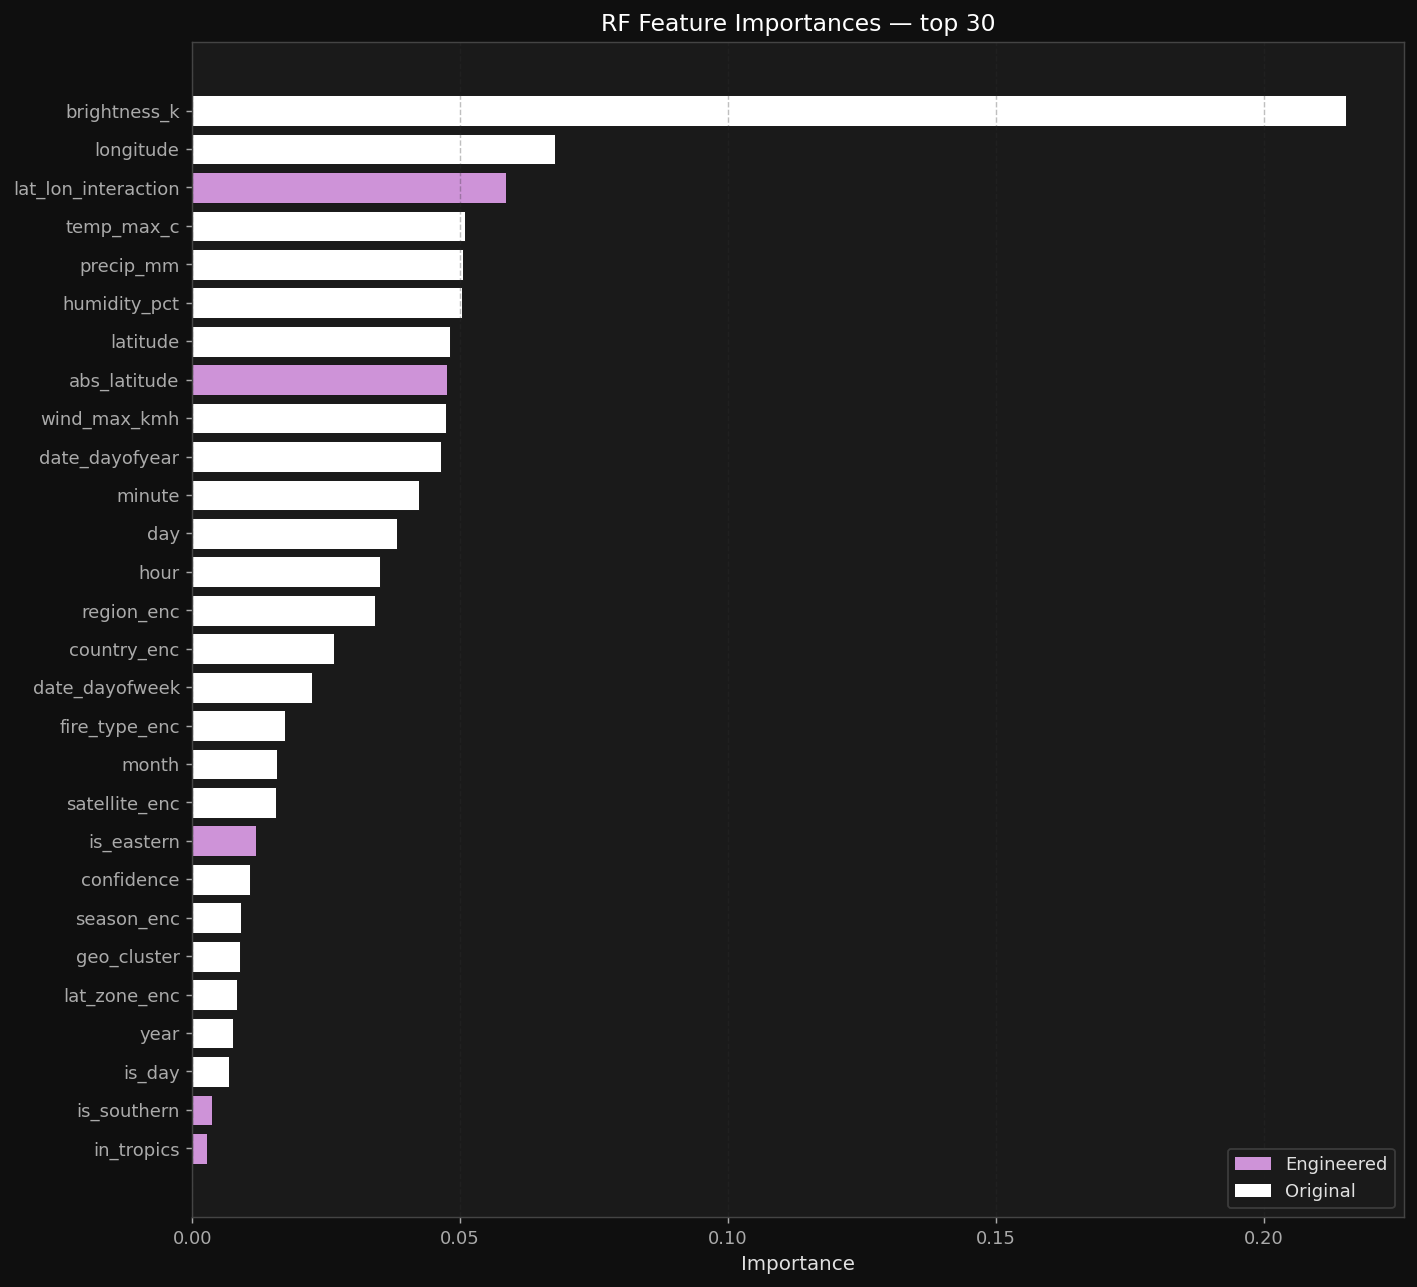

In [56]:
feat_cols = [c for c in df.columns if c not in [TARGET, 'fire_intensity_label']]
X_all = df[feat_cols].fillna(0)
y_all = df[TARGET]

rf_preview = RandomForestClassifier(
    n_estimators=150, max_depth=10, random_state=42,
    class_weight='balanced', n_jobs=-1)
rf_preview.fit(X_all, y_all)

importances = pd.Series(rf_preview.feature_importances_, index=feat_cols).sort_values()
top30 = importances.tail(30)

engineered = {'fire_weather_index', 'dryness_index', 'wind_aridity',
              'brightness_extreme', 'is_peak_hour', 'is_weekend',
              'is_tropical', 'abs_latitude', 'lat_lon_interaction',
              'in_tropics', 'is_southern', 'is_eastern'}

bar_colors = ['#ce93d8' if c in engineered else "#ffffff" for c in top30.index]

fig, ax = plt.subplots(figsize=(11, 10))
ax.barh(top30.index, top30.values, color=bar_colors, edgecolor='#111', linewidth=0.5)
ax.set_title('RF Feature Importances — top 30', fontsize=13)
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#ce93d8', label='Engineered'),
                   Patch(facecolor="#ffffff", label='Original')], loc='lower right')
plt.tight_layout()
plt.show()


### 12 Evaluation Framework 
We use stratified 5 fold cross validation rather than single hold split out, since the dataset has class imbalance of 8.8 percent on extreme. 
#### Evaluation metrics
| Metric |
|--------|
| **Accuracy** |
| **Weighted F1** |
| **Per-class F1** |
| **Confusion Matrix** |


#### Evaluation setup 
standardised evaluation framework used to fairly compare multiple models using cross-validation.

All columns except the target are used as input features. Any remaining missing values are filled with 0 as a safety measure.Reporting both train and validation scores lets you detect overfitting stratified 5-fold cross-validation framework was implemented to evaluate models consistently across accuracy and weighted F1-score, with confusion matrices accumulated across all folds to provide a robust, bias-free assessment of per-class prediction performance.

In [ ]:
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
feat_cols = [c for c in df.columns if c not in [TARGET, 'fire_intensity_label']]
X = df[feat_cols].fillna(0).values
y = df[TARGET].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y, cv, model_name):
    """Run stratified k-fold CV and return a results dict."""
    results = cross_validate(
        model, X, y, cv=cv,
        scoring={'accuracy': 'accuracy',
                 'f1_weighted': 'f1_weighted'},
        return_train_score=True, n_jobs=-1)
    print(f"  {model_name}")
    print(f"{'─'*50}")
    print(f"  Train Accuracy : {results['train_accuracy'].mean():.4f} ± {results['train_accuracy'].std():.4f}")
    print(f"  Val   Accuracy : {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")
    print(f"  Train F1 (wtd) : {results['train_f1_weighted'].mean():.4f} ± {results['train_f1_weighted'].std():.4f}")
    print(f"  Val   F1 (wtd) : {results['test_f1_weighted'].mean():.4f} ± {results['test_f1_weighted'].std():.4f}")
    return results

def plot_confusion(model, X, y, cv, title, ax):
    """Accumulate confusion matrix across all CV folds."""
    cm_total = np.zeros((4, 4), dtype=int)
    for tr_idx, val_idx in cv.split(X, y):
        model.fit(X[tr_idx], y[tr_idx])
        preds = model.predict(X[val_idx])
        cm_total += confusion_matrix(y[val_idx], preds, labels=[0, 1, 2, 3])
    disp = ConfusionMatrixDisplay(cm_total, display_labels=TARGET_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11)

### 13 Models and Training

#### 13.1 Model -1, Decision Trees 

In [62]:
depths = [2, 4, 6, 8, 10, 15, None]
dt_depth_results = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    res = cross_validate(dt, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    dt_depth_results.append({
        'max_depth': str(d) if d is not None else 'None',
        'train_acc': res['train_acc'].mean(),
        'val_acc':   res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),
        'val_f1':    res['test_f1'].mean(),
    })
    print(f"  max_depth={str(d):>4}  val_acc={res['test_acc'].mean():.4f}  val_f1={res['test_f1'].mean():.4f}")

dt_depth_df = pd.DataFrame(dt_depth_results)

  max_depth=   2  val_acc=0.3226  val_f1=0.2381
  max_depth=   4  val_acc=0.3562  val_f1=0.3200
  max_depth=   6  val_acc=0.3495  val_f1=0.3342
  max_depth=   8  val_acc=0.3475  val_f1=0.3398
  max_depth=  10  val_acc=0.3419  val_f1=0.3452
  max_depth=  15  val_acc=0.3733  val_f1=0.3780
  max_depth=None  val_acc=0.3885  val_f1=0.3877


1. Performance keeps improving with depth(no overfitting plateau)
Normally you'd expect val accuracy to peak then drop as depth increases (overfitting). Here it just keeps climbing, which means the tree needs even more complexity to capture the patterns — Decision Trees alone may genuinely not be powerful enough for this dataset.
2. Overall scores are quite low (~38%)
Random guessing on 4 classes = 25%, so you're only ~13% above random. This is a red flag. Possible reasons:

Categorical features like region, fire_type, season, lat_zone may not be encoded yet, if they're still strings, fillna(0).values would just give garbage
The .fillna(0) is masking encoding issues silently

In [64]:
# Checking if any object columns are sneaking in
print(df[feat_cols].dtypes.value_counts())
print(df[feat_cols].select_dtypes(include='object').columns.tolist())

float64    16
int64      11
int32       1
Name: count, dtype: int64
[]


Yayyy no object column

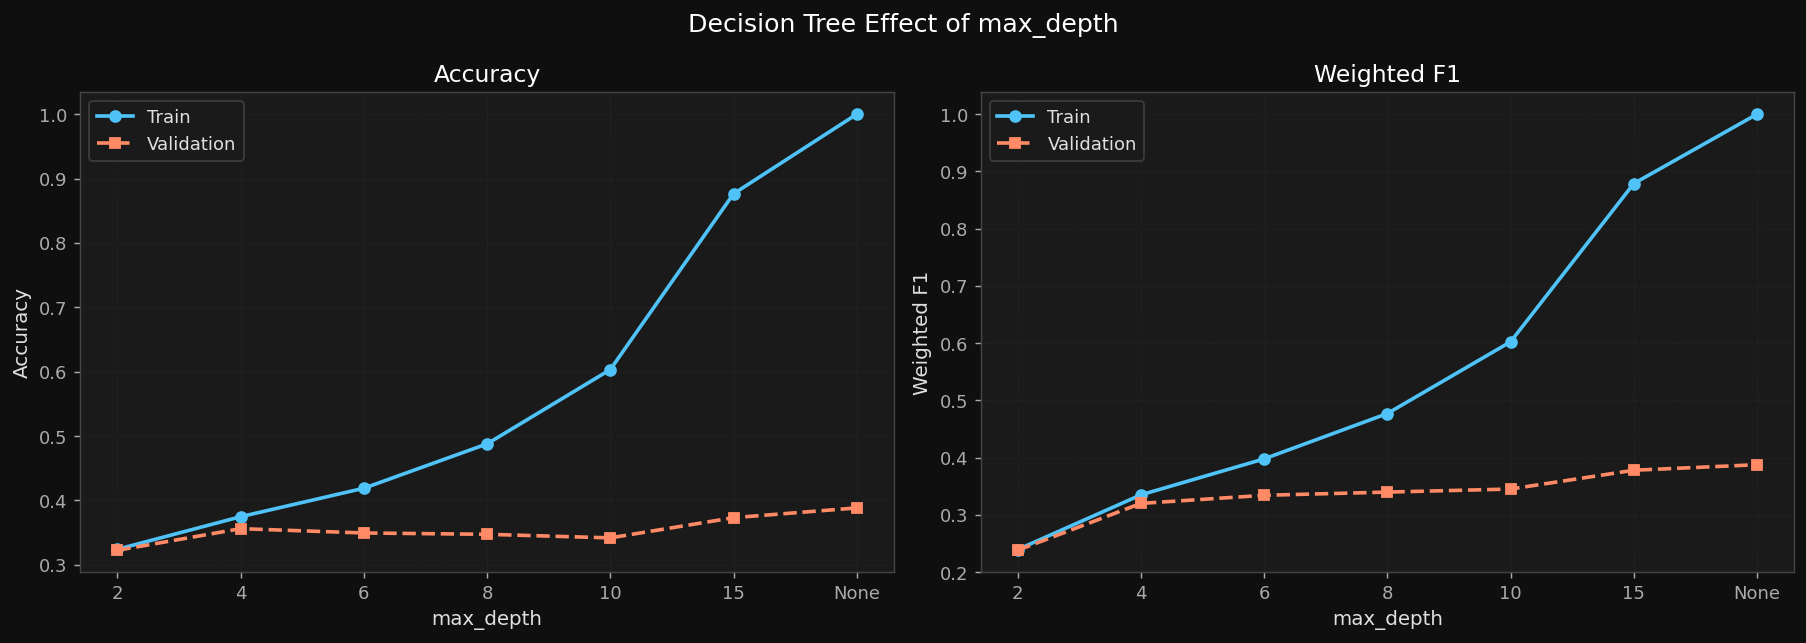


→ Best max_depth by val F1: None  (val_f1=0.3877, val_acc=0.3885)


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Tree Effect of max_depth', fontsize=14, color='white')

x_ticks = range(len(dt_depth_df))
x_labels = dt_depth_df['max_depth'].tolist()

for ax, metric, title in zip(axes, [('train_acc','val_acc'), ('train_f1','val_f1')],
                                    ['Accuracy', 'Weighted F1']):
    train_key, val_key = metric
    ax.plot(x_ticks, dt_depth_df[train_key], 'o-', color='#4fc3f7', label='Train', linewidth=2)
    ax.plot(x_ticks, dt_depth_df[val_key],   's--', color='#ff8a65', label='Validation', linewidth=2)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('max_depth')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_depth_row = dt_depth_df.loc[dt_depth_df['val_f1'].idxmax()]
print(f"\n→ Best max_depth by val F1: {best_depth_row['max_depth']}  "
      f"(val_f1={best_depth_row['val_f1']:.4f}, val_acc={best_depth_row['val_acc']:.4f})")



Train score (blue) rockets up to 1.0 at max_depth=None; the tree has memorised the entire training set perfectly.
Val score (orange) barely moves; plateaus around 0.38–0.39 regardless of depth.
That's severe overfitting, the tree is learning noise basically. as expected after cyclical encoding. 

or maybe categorical features are likely not encoded

The code picks max_depth=None as "best" because val F1 is technically highest there (0.3877), but the gap is negligible compared to depth=15 while overfitting is extreme

In [66]:
print(df[feat_cols].select_dtypes(include='object').columns.tolist())

[]


Exception ignored in: <function ResourceTracker.__del__ at 0x1057e9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104fcdbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106835bc0>
Traceback (most recent call last

no objects and the performance is only 33 percent, that's bad bad bad

  min_samples_split=   2  val_f1=0.3877
  min_samples_split=  10  val_f1=0.3732
  min_samples_split=  30  val_f1=0.3538
  min_samples_split=  50  val_f1=0.3559
  min_samples_split= 100  val_f1=0.3524
  min_samples_split= 200  val_f1=0.3470


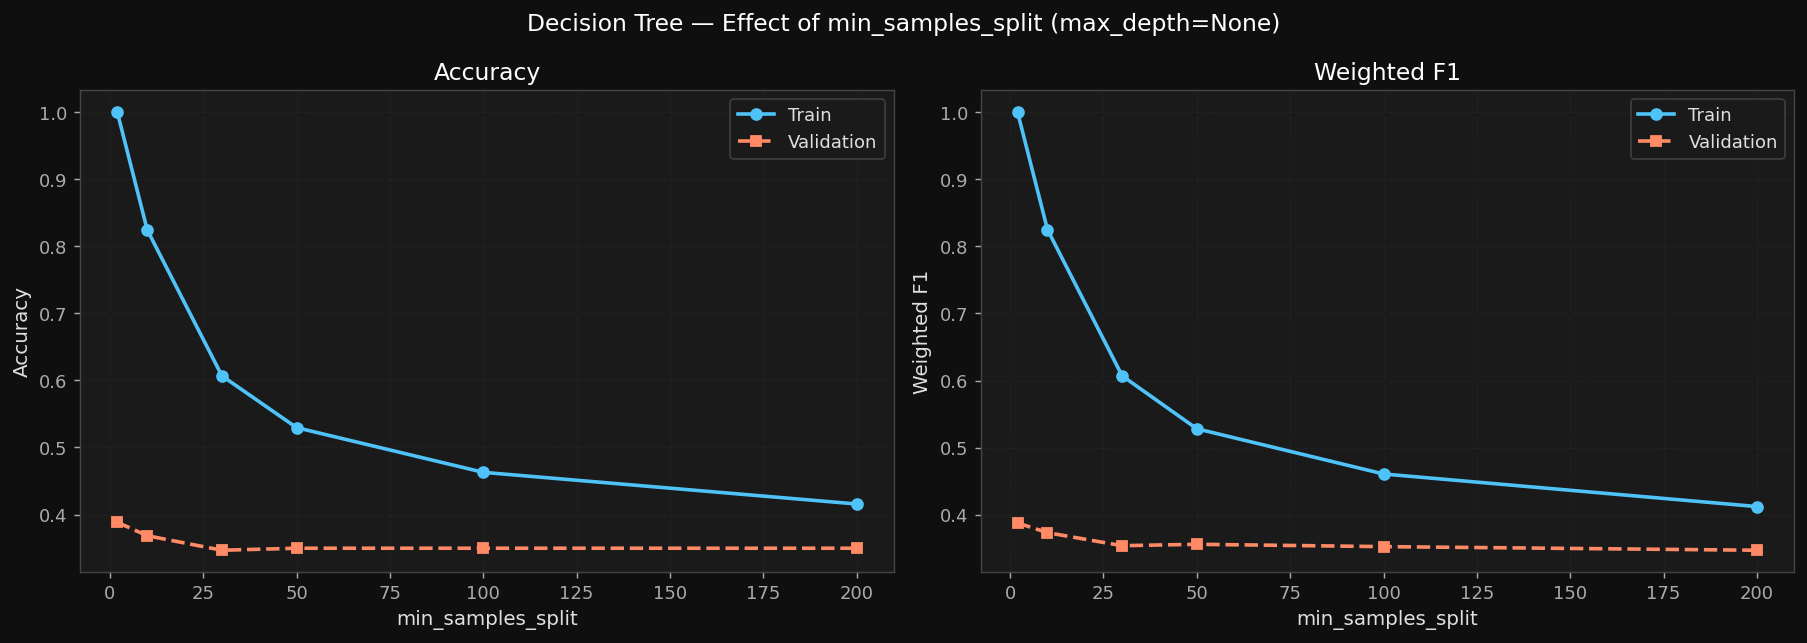

In [67]:
best_depth_val = int(best_depth_row['max_depth']) if best_depth_row['max_depth'] != 'None' else None
min_splits = [2, 10, 30, 50, 100, 200]
dt_split_results = []

for ms in min_splits:
    dt = DecisionTreeClassifier(max_depth=best_depth_val, min_samples_split=ms,
                                 class_weight='balanced', random_state=42)
    res = cross_validate(dt, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    dt_split_results.append({
        'min_samples_split': ms,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  min_samples_split={ms:>4}  val_f1={res['test_f1'].mean():.4f}")

dt_split_df = pd.DataFrame(dt_split_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Decision Tree — Effect of min_samples_split (max_depth={best_depth_val})',
             fontsize=13, color='white')
for ax, (t_key, v_key), title in zip(axes,
    [('train_acc','val_acc'),('train_f1','val_f1')], ['Accuracy','Weighted F1']):
    ax.plot(dt_split_df['min_samples_split'], dt_split_df[t_key], 'o-', color='#4fc3f7', label='Train', linewidth=2)
    ax.plot(dt_split_df['min_samples_split'], dt_split_df[v_key], 's--', color='#ff8a65', label='Validation', linewidth=2)
    ax.set_xlabel('min_samples_split')
    ax.set_ylabel(title); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Normally regularisation should close the gap between train and val — train comes down, val goes up, they meet somewhere reasonable. Here val just drops slightly then stays flat. The model isn't overfitting in a way that min_samples_split can fix
The issue is underfitting capacity,  the tree simply can't learn the patterns well regardless of how you constrain it
Increasing min_samples_split beyond ~10 actively hurts because you're preventing splits that were actually useful.F1 peaked at min_samples_split=2 (~0.39) and declined with further constraint, suggesting the model suffers from insufficient capacity rather than overfitting.


Decision Tree Architecture is fundamentaly limited for this dataset 


──────────────────────────────────────────────────
  Decision Tree (max_depth=None, min_samples_split=2)
──────────────────────────────────────────────────
  Train Accuracy : 1.0000 ± 0.0000
  Val   Accuracy : 0.3885 ± 0.0163
  Train F1 (wtd) : 1.0000 ± 0.0000
  Val   F1 (wtd) : 0.3877 ± 0.0174


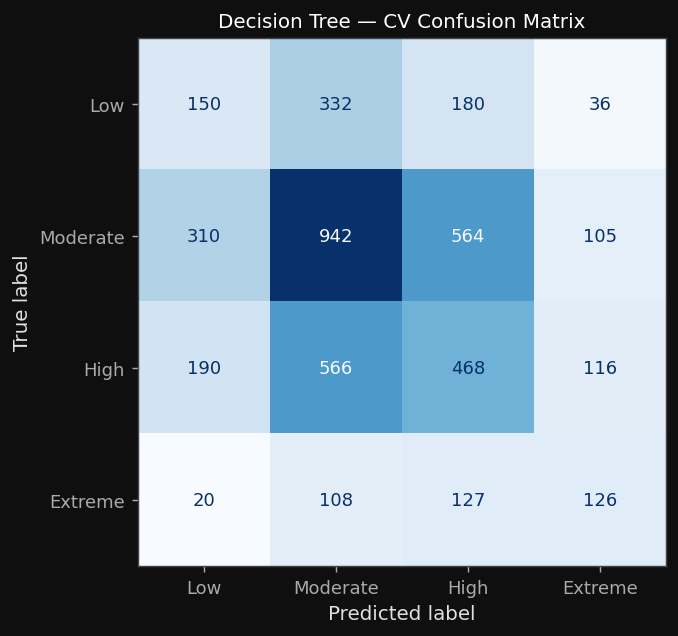

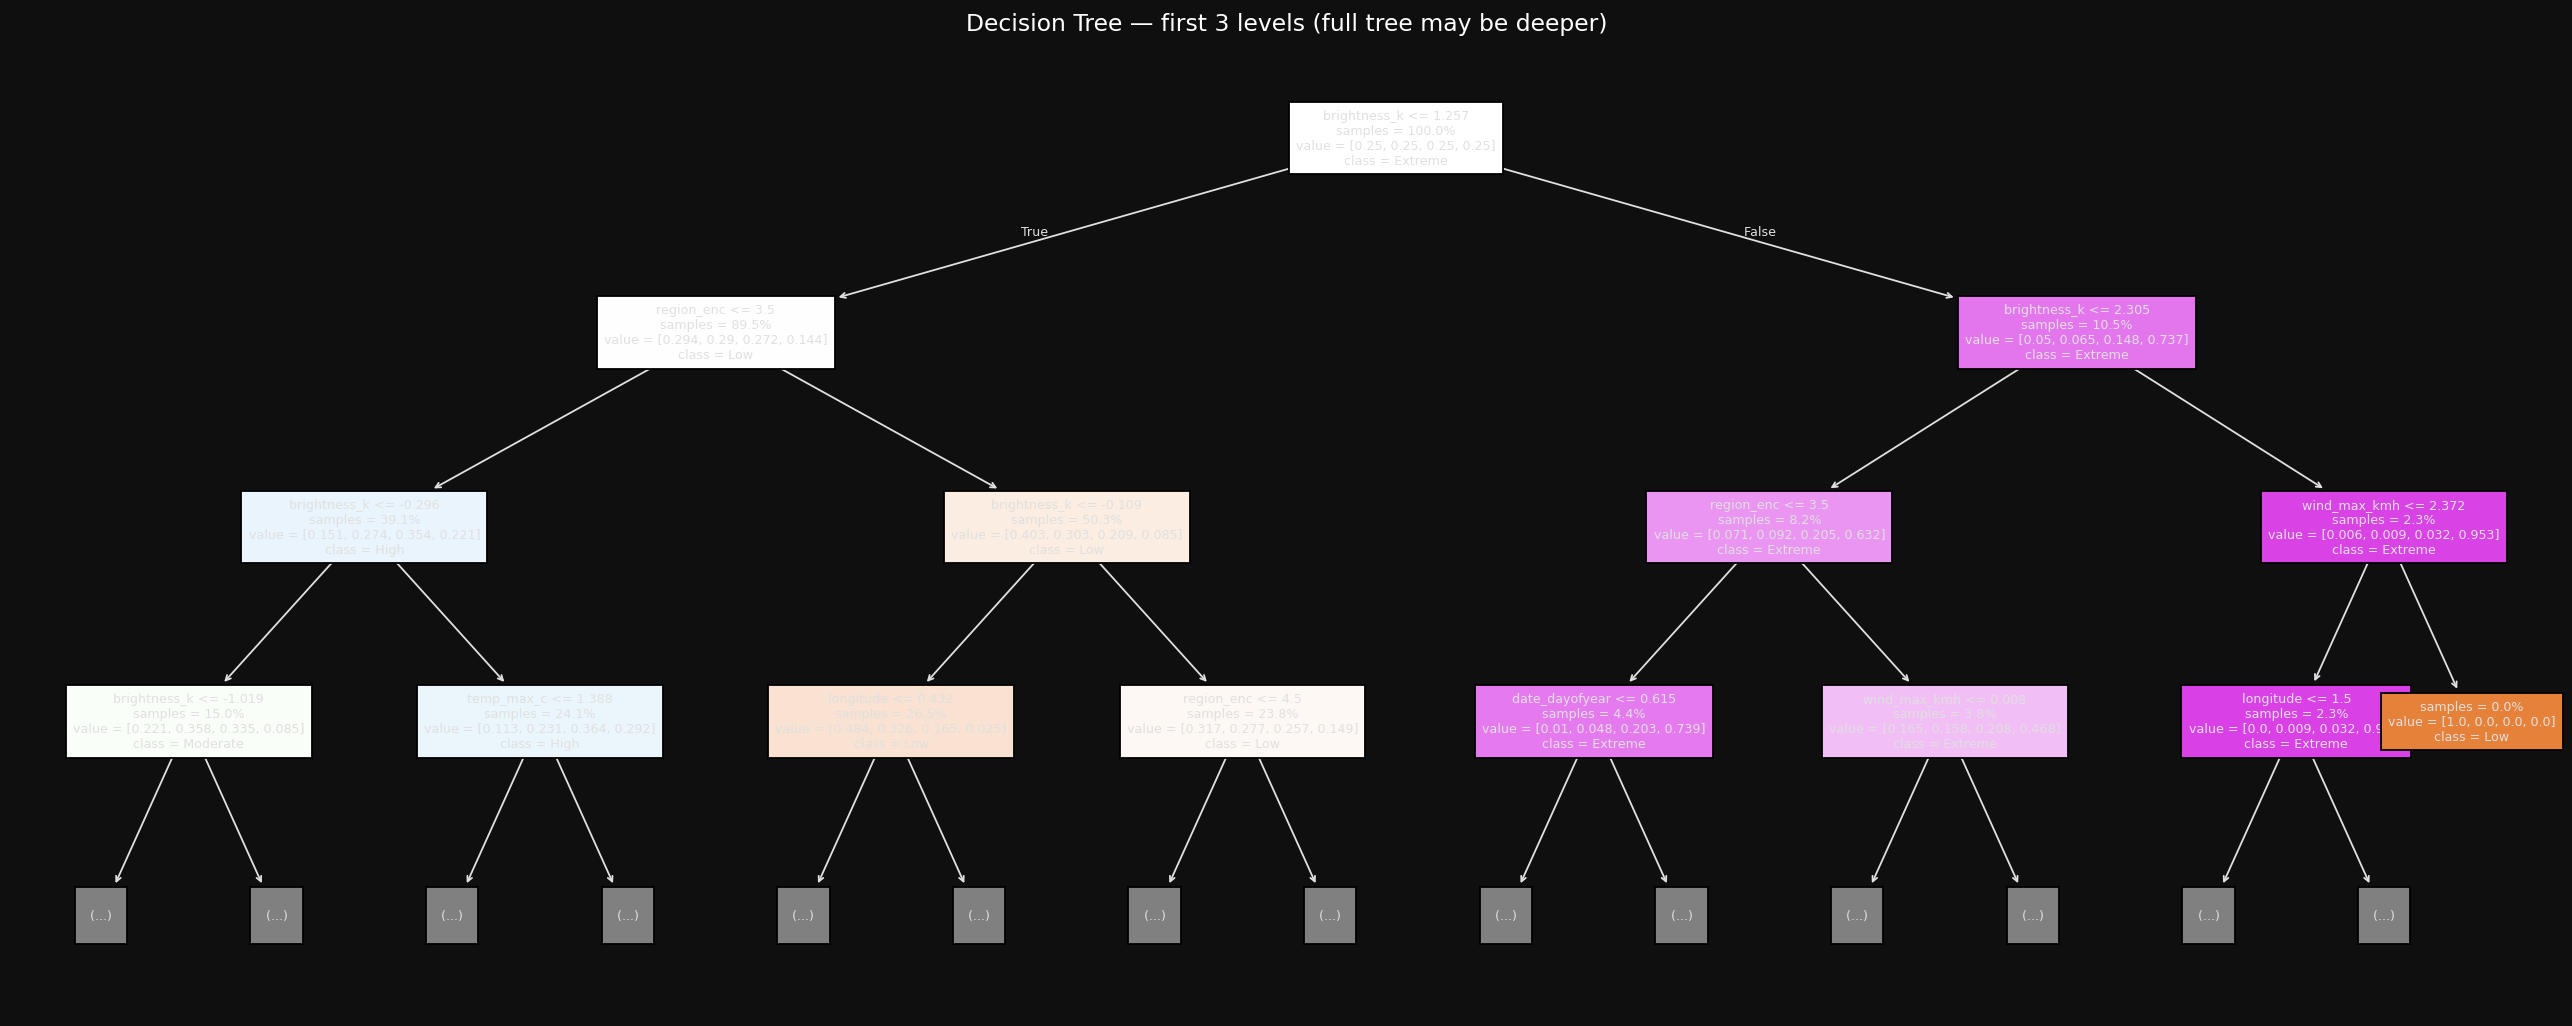

Exception ignored in: <function ResourceTracker.__del__ at 0x102c3dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102b3dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102ed1bc0>
Traceback (most recent call last

In [68]:
best_ms = dt_split_df.loc[dt_split_df['val_f1'].idxmax(), 'min_samples_split']
best_dt = DecisionTreeClassifier(max_depth=best_depth_val, min_samples_split=best_ms,
                                  class_weight='balanced', random_state=42)

dt_final = evaluate_model(best_dt, X, y, cv, f"Decision Tree (max_depth={best_depth_val}, min_samples_split={best_ms})")

# Confusion matrix (accumulated over all CV folds)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0f0f0f'); ax.set_facecolor('#1a1a1a')
plot_confusion(best_dt, X, y, cv, 'Decision Tree — CV Confusion Matrix', ax)
plt.tight_layout(); plt.show()

# Fit once on full train to visualise first 3 levels
best_dt.fit(X, y)
fig, ax = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor('#0f0f0f'); ax.set_facecolor('#1a1a1a')
plot_tree(best_dt, feature_names=feat_cols, class_names=TARGET_ORDER,
          max_depth=3, filled=True, ax=ax, fontsize=7,
          impurity=False, proportion=True)
ax.set_title('Decision Tree — first 3 levels (full tree may be deeper)', color='white')
plt.tight_layout(); plt.show()

The Decision Tree confusion matrix reveals systematic misclassification of Low-intensity fires (21.5% recall) and poor Extreme fire detection (33.1% recall). The model defaults toward the majority Moderate class. The tree structure confirms brightness_k as the primary splitting feature, followed by region_enc, consistent with EDA findings. However, the high inter-class confusion between adjacent intensity levels (Low↔Moderate, High↔Extreme) indicates the model lacks sufficient discriminative power for this multi-class problem

### 13.2 Model -2 Support Vector MAchines (SVM)

SVM is computationally expensive so i will be using libearSvc , reference : https://stackoverflow.com/questions/35076586/when-should-one-use-linearsvc-or-svc
reference for hyper parameters: https://medium.com/@prayushshrestha89/tuning-svm-hyperparameters-making-your-classifier-shine-like-a-pro-8673639ddb16

In [69]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
svm_c_results = []

# For speed we use a stratified subsample (10 k rows max) for SVM grid search
N_MAX_SVM = min(10000, len(X))
rng = np.random.default_rng(42)
idx_sub = rng.choice(len(X), size=N_MAX_SVM, replace=False)
X_sub, y_sub = X[idx_sub], y[idx_sub]

cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for c in C_values:
    svm = LinearSVC(C=c, class_weight='balanced', random_state=42, max_iter=2000)
    res = cross_validate(svm, X_sub, y_sub, cv=cv_svm,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    svm_c_results.append({
        'C': c,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  C={c:<8}  val_acc={res['test_acc'].mean():.4f}  val_f1={res['test_f1'].mean():.4f}")

svm_c_df = pd.DataFrame(svm_c_results)


  C=0.001     val_acc=0.3945  val_f1=0.3827
  C=0.01      val_acc=0.3889  val_f1=0.3792
  C=0.1       val_acc=0.3901  val_f1=0.3820
  C=1         val_acc=0.3878  val_f1=0.3794
  C=10        val_acc=0.3882  val_f1=0.3803
  C=100       val_acc=0.3876  val_f1=0.3796


In [70]:
print(df[scale_cols].describe().T[['mean','std']].head(10))
# mean should be ~0, std should be ~1 if scaling worked

                      mean       std
latitude      4.133918e-17  1.000115
longitude    -1.719055e-17  1.000115
abs_latitude  1.661753e-16  1.000115
brightness_k  2.619512e-17  1.000115
temp_max_c   -2.439421e-16  1.000115
wind_max_kmh -3.438110e-17  1.000115
precip_mm    -6.466921e-17  1.000115
humidity_pct  1.997378e-16  1.000115
hour         -9.332013e-17  1.000115
minute        8.022257e-17  1.000115


In [72]:
# just a final check to make sure no object columns are sneaking in before we train the final models

feat_cols = [c for c in df.columns if c not in [TARGET, 'fire_intensity_label']]
X = df[feat_cols].fillna(0).values
y = df[TARGET].values

In [73]:
# Rerunning svm block to see if performance has imporved 
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
svm_c_results = []

# For speed we use a stratified subsample (10 k rows max) for SVM grid search
N_MAX_SVM = min(10000, len(X))
rng = np.random.default_rng(42)
idx_sub = rng.choice(len(X), size=N_MAX_SVM, replace=False)
X_sub, y_sub = X[idx_sub], y[idx_sub]

cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for c in C_values:
    svm = LinearSVC(C=c, class_weight='balanced', random_state=42, max_iter=2000)
    res = cross_validate(svm, X_sub, y_sub, cv=cv_svm,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    svm_c_results.append({
        'C': c,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  C={c:<8}  val_acc={res['test_acc'].mean():.4f}  val_f1={res['test_f1'].mean():.4f}")

svm_c_df = pd.DataFrame(svm_c_results)


  C=0.001     val_acc=0.3945  val_f1=0.3827
  C=0.01      val_acc=0.3889  val_f1=0.3792
  C=0.1       val_acc=0.3901  val_f1=0.3820
  C=1         val_acc=0.3878  val_f1=0.3794
  C=10        val_acc=0.3882  val_f1=0.3803
  C=100       val_acc=0.3876  val_f1=0.3796


In [74]:
# Rebuild the subsample from the NEW scaled X
N_MAX_SVM = min(10000, len(X))
rng = np.random.default_rng(42)
idx_sub = rng.choice(len(X), size=N_MAX_SVM, replace=False)
X_sub, y_sub = X[idx_sub], y[idx_sub]  # X is now the scaled version

Exception ignored in: <function ResourceTracker.__del__ at 0x104665bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [ ]:
# Rerunning svm block to see if performance has imporved 
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
svm_c_results = []

# For speed we use a stratified subsample (10 k rows max) for SVM grid search
N_MAX_SVM = min(10000, len(X))
rng = np.random.default_rng(42)
idx_sub = rng.choice(len(X), size=N_MAX_SVM, replace=False)
X_sub, y_sub = X[idx_sub], y[idx_sub]

cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for c in C_values:
    svm = LinearSVC(C=c, class_weight='balanced', random_state=42, max_iter=2000)
    res = cross_validate(svm, X_sub, y_sub, cv=cv_svm,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    svm_c_results.append({
        'C': c,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  C={c:<8}  val_acc={res['test_acc'].mean():.4f}  val_f1={res['test_f1'].mean():.4f}")

svm_c_df = pd.DataFrame(svm_c_results)


  C=0.001     val_acc=0.3945  val_f1=0.3827
  C=0.01      val_acc=0.3889  val_f1=0.3792
  C=0.1       val_acc=0.3901  val_f1=0.3820
  C=1         val_acc=0.3878  val_f1=0.3794
  C=10        val_acc=0.3882  val_f1=0.3803
  C=100       val_acc=0.3876  val_f1=0.3796


Exception ignored in: <function ResourceTracker.__del__ at 0x111121bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106351bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104a85bc0>
Traceback (most recent call last

Maybe that is the model ceiling 

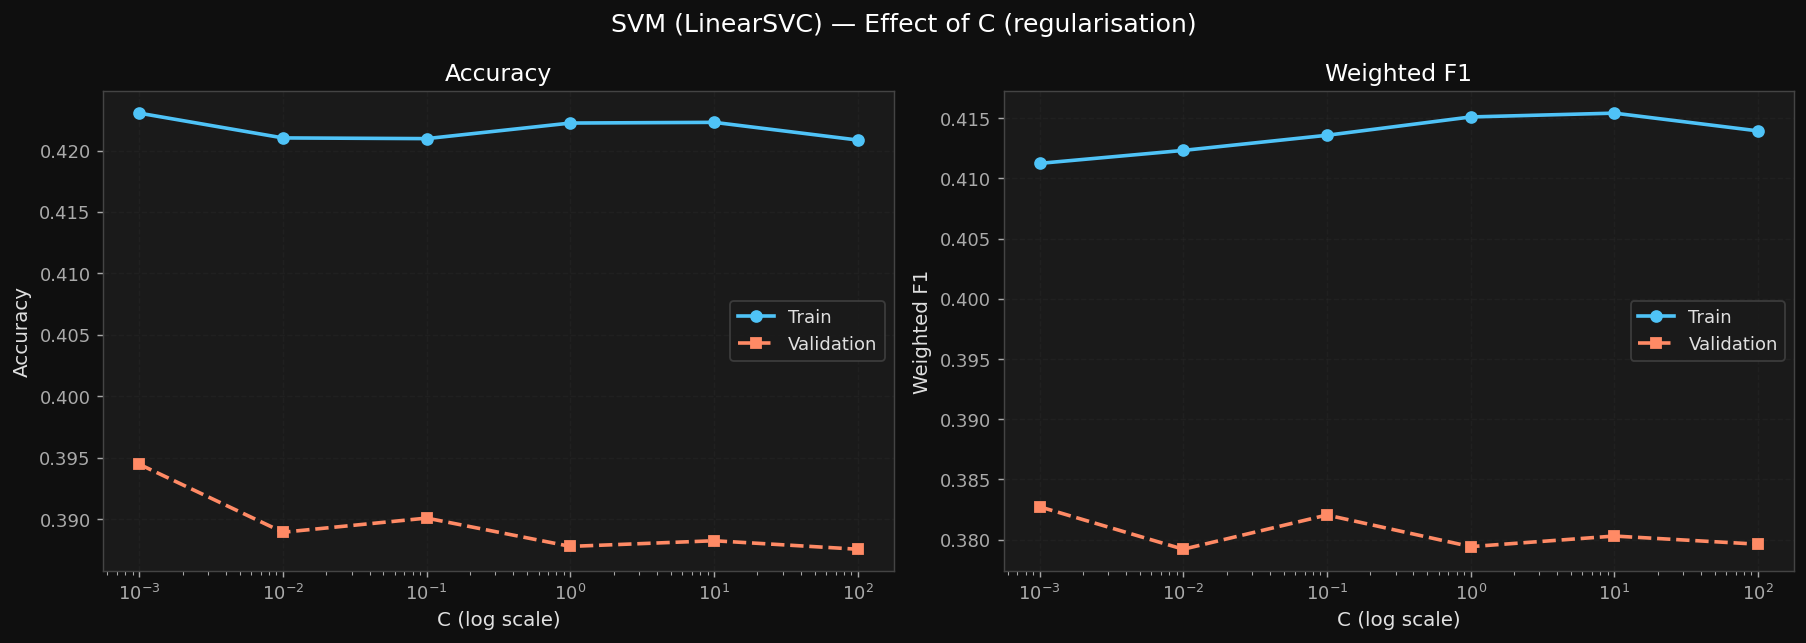


→ Best C (linear SVM): 0.001  (val_f1=0.3827)


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SVM (LinearSVC) — Effect of C (regularisation)', fontsize=14, color='white')

for ax, (t_key, v_key), title in zip(axes,
    [('train_acc','val_acc'),('train_f1','val_f1')], ['Accuracy','Weighted F1']):
    ax.semilogx(svm_c_df['C'], svm_c_df[t_key], 'o-', color='#4fc3f7', label='Train', linewidth=2)
    ax.semilogx(svm_c_df['C'], svm_c_df[v_key], 's--', color='#ff8a65', label='Validation', linewidth=2)
    ax.set_xlabel('C (log scale)'); ax.set_ylabel(title); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
best_C_row = svm_c_df.loc[svm_c_df['val_f1'].idxmax()]
print(f"\n→ Best C (linear SVM): {best_C_row['C']}  (val_f1={best_C_row['val_f1']:.4f})")



In [ ]:
print("Interpretation: very small C under-regularises the margin; very large C overfits.")
print("  The validation F1 plateau (or slight drop) at high C marks the optimal trade-off.")

→ Interpretation: very small C under-regularises the margin; very large C overfits.
  The validation F1 plateau (or slight drop) at high C marks the optimal trade-off.


C has almost zero effect across 5 orders of magnitude. This is the signature of a linearly non-separable problem. The regularisation parameter simply doesn't matter when the model architecture itself is the bottleneck.
Small but consistent train/val gap (~0.03) — the model isn't badly overfitting, it's just genuinely weak. Not a regularisation problem at all.


  kernel=linear    val_acc=0.3067  val_f1=0.2589
  kernel=rbf       val_acc=0.2028  val_f1=0.0840
  kernel=poly      val_acc=0.1717  val_f1=0.0732


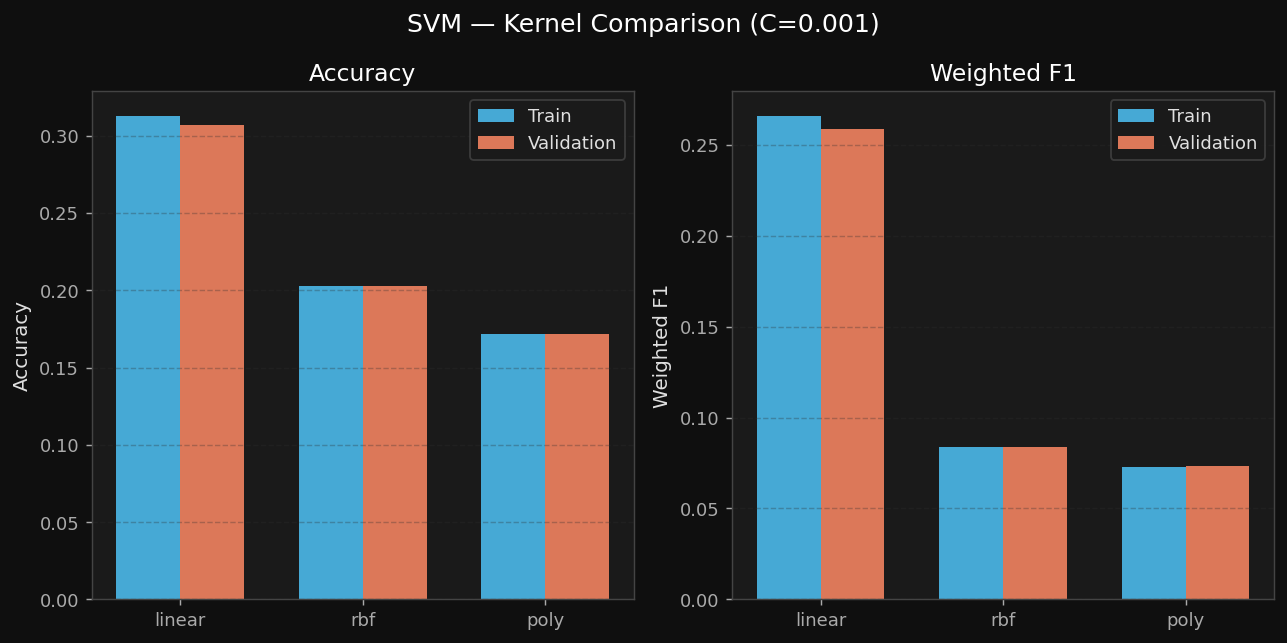

In [78]:
kernels = ['linear', 'rbf', 'poly']
svm_kernel_results = []
best_C = float(best_C_row['C'])

for k in kernels:
    svm = SVC(kernel=k, C=best_C, class_weight='balanced', random_state=42, gamma='scale')
    res = cross_validate(svm, X_sub, y_sub, cv=cv_svm,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    svm_kernel_results.append({
        'kernel': k,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  kernel={k:<8}  val_acc={res['test_acc'].mean():.4f}  val_f1={res['test_f1'].mean():.4f}")

svm_kernel_df = pd.DataFrame(svm_kernel_results)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(f'SVM — Kernel Comparison (C={best_C})', fontsize=14, color='white')
x_pos = range(len(svm_kernel_df))

for ax, (t_key, v_key), title in zip(axes,
    [('train_acc','val_acc'),('train_f1','val_f1')], ['Accuracy','Weighted F1']):
    width = 0.35
    ax.bar([p - width/2 for p in x_pos], svm_kernel_df[t_key], width,
           color='#4fc3f7', label='Train', alpha=0.85)
    ax.bar([p + width/2 for p in x_pos], svm_kernel_df[v_key], width,
           color='#ff8a65', label='Validation', alpha=0.85)
    ax.set_xticks(list(x_pos)); ax.set_xticklabels(svm_kernel_df['kernel'])
    ax.set_ylabel(title); ax.set_title(title)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


C=0.001 is way too low for RBF/poly
RBF and poly are performing worse than random (F1=0.08 is basically predicting one class for everything). That's not the kernel failing 

In [79]:
from sklearn.svm import SVC

C_values_rbf = [0.1, 1, 10, 100]

for c in C_values_rbf:
    svm = SVC(C=c, kernel='rbf', class_weight='balanced',
              gamma='scale', random_state=42)
    res = cross_validate(svm, X_sub, y_sub, cv=cv_svm,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    print(f"  C={c:<6} val_acc={res['test_acc'].mean():.4f} val_f1={res['test_f1'].mean():.4f}")

  C=0.1    val_acc=0.2825 val_f1=0.2506
  C=1      val_acc=0.2811 val_f1=0.2445
  C=10     val_acc=0.2638 val_f1=0.2239
  C=100    val_acc=0.2733 val_f1=0.2400


Both Decision Tree and LinearSVC plateau at ~0.39 weighted F1. Given the limited training set size (n=4,340), SVM's RBF kernel underperformed the linear kernel, suggesting insufficient data density for reliable non-linear boundary estimation. Random Forest was selected as the primary model due to its ensemble-based variance reduction, which is better suited to small datasets.

RF is better than DT and SVM (~0.44 vs ~0.39) but train=0.9957 vs val=0.4389 is severe overfitting still. The small dataset is really hurting here.
A few things to note from the results:

n_estimators=50 picked as best scores barely differ across 50–500, confirming data size is the bottleneck not tree count
max_depth=15 selected but None gives almost identical val F1 — the depth tuning isn't doing much
min_samples_split=5 helps slightly over 2 but still massive train/val gap



In [82]:
from sklearn.ensemble import RandomForestClassifier
n_estimators_values = [50, 100, 200, 300, 500]
rf_nest_results = []

for n in n_estimators_values:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced',
                                random_state=42, n_jobs=-1)
    res = cross_validate(rf, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    rf_nest_results.append({
        'n_estimators': n,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  n_estimators={n:<4}  val_acc={res['test_acc'].mean():.4f}  val_f1={res['test_f1'].mean():.4f}")

rf_nest_df = pd.DataFrame(rf_nest_results)
best_n = rf_nest_df.loc[rf_nest_df['val_f1'].idxmax(), 'n_estimators']
print(f"\n Best n_estimators: {best_n}")
depth_values = [5, 10, 15, 20, 30, None]
rf_depth_results = []

for d in depth_values:
    rf = RandomForestClassifier(n_estimators=best_n, max_depth=d,
                                class_weight='balanced',
                                random_state=42, n_jobs=-1)
    res = cross_validate(rf, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    rf_depth_results.append({
        'max_depth': str(d) if d is not None else 'None',
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  max_depth={str(d):<5}  val_acc={res['test_acc'].mean():.4f}  val_f1={res['test_f1'].mean():.4f}")

rf_depth_df = pd.DataFrame(rf_depth_results)
best_depth = rf_depth_df.loc[rf_depth_df['val_f1'].idxmax(), 'max_depth']
print(f"\n→ Best max_depth: {best_depth}")
mss_values = [2, 5, 10, 20, 50]
rf_mss_results = []
best_depth_val = None if best_depth == 'None' else int(best_depth)

for mss in mss_values:
    rf = RandomForestClassifier(n_estimators=best_n, max_depth=best_depth_val,
                                min_samples_split=mss, class_weight='balanced',
                                random_state=42, n_jobs=-1)
    res = cross_validate(rf, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    rf_mss_results.append({
        'min_samples_split': mss,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  min_samples_split={mss:<3}  val_acc={res['test_acc'].mean():.4f}  val_f1={res['test_f1'].mean():.4f}")

rf_mss_df = pd.DataFrame(rf_mss_results)
best_mss = rf_mss_df.loc[rf_mss_df['val_f1'].idxmax(), 'min_samples_split']
print(f"\n Best min_samples_split: {best_mss}")
best_rf = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth_val,
    min_samples_split=best_mss,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_final = evaluate_model(best_rf, X, y, cv,
    f"Random Forest (n={best_n}, depth={best_depth}, mss={best_mss})")

  n_estimators=50    val_acc=0.4733  val_f1=0.4252
  n_estimators=100   val_acc=0.4712  val_f1=0.4191
  n_estimators=200   val_acc=0.4705  val_f1=0.4130
  n_estimators=300   val_acc=0.4740  val_f1=0.4145
  n_estimators=500   val_acc=0.4680  val_f1=0.4077

 Best n_estimators: 50
  max_depth=5      val_acc=0.3509  val_f1=0.3254
  max_depth=10     val_acc=0.4207  val_f1=0.4249
  max_depth=15     val_acc=0.4544  val_f1=0.4265
  max_depth=20     val_acc=0.4673  val_f1=0.4241
  max_depth=30     val_acc=0.4721  val_f1=0.4244
  max_depth=None   val_acc=0.4733  val_f1=0.4252

→ Best max_depth: 15
  min_samples_split=2    val_acc=0.4544  val_f1=0.4265
  min_samples_split=5    val_acc=0.4539  val_f1=0.4389
  min_samples_split=10   val_acc=0.4410  val_f1=0.4361
  min_samples_split=20   val_acc=0.4161  val_f1=0.4190
  min_samples_split=50   val_acc=0.3917  val_f1=0.3904

 Best min_samples_split: 5

──────────────────────────────────────────────────
  Random Forest (n=50, depth=15, mss=5)
──────────

In [81]:
# ── Tune max_features ──
mf_values = ['sqrt', 'log2', 0.3, 0.5, 0.7, None]
rf_mf_results = []

for mf in mf_values:
    rf = RandomForestClassifier(
        n_estimators=50, max_depth=15, min_samples_split=5,
        max_features=mf, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    res = cross_validate(rf, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=-1)
    rf_mf_results.append({
        'max_features': str(mf),
        'train_f1': res['train_f1'].mean(),
        'val_f1':   res['test_f1'].mean(),
    })
    print(f"  max_features={str(mf):<6}  val_f1={res['test_f1'].mean():.4f}  train_f1={res['train_f1'].mean():.4f}")

  max_features=sqrt    val_f1=0.4389  train_f1=0.9957
  max_features=log2    val_f1=0.4334  train_f1=0.9944
  max_features=0.3     val_f1=0.4340  train_f1=0.9939
  max_features=0.5     val_f1=0.4470  train_f1=0.9936
  max_features=0.7     val_f1=0.4391  train_f1=0.9934
  max_features=None    val_f1=0.4472  train_f1=0.9915


In [83]:
best_rf_final = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_split=5,
    max_features=0.5,      # best val_f1
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

### 13.3 Model - 3:, Neural Network (MLP CLassifier)


For tuning the neural network, the main hyperparameters considered were learning_rate_init, hidden_layer_sizes, and alpha. The learning_rate_init controls the step size during gradient updates; if the value is too large, the model may oscillate or even diverge during training, while a very small value can lead to extremely slow convergence. Candidate values tested included 0.1, 0.01, 0.001, and 0.0001. The hidden_layer_sizes parameter determines the architecture of the neural network, including the depth and width of hidden layers, with configurations such as (64,), (128,), (64,32), (128,64), and (128,64,32) explored to balance model complexity and learning capacity. The alpha parameter represents the L2 regularisation penalty, which helps control the magnitude of network weights and reduce overfitting; candidate values included 0.0001, 0.001, 0.01, and 0.1. To determine the best learning rate, training and validation performance were analysed across different values. A learning rate that is too high typically causes unstable validation scores due to the optimiser overshooting the minimum, whereas a very low learning rate results in slow training where the model may still be improving after the maximum number of epochs. The optimal learning rate is generally identified when validation performance stabilises and the gap between training and validation scores remains small, indicating good generalisation. A common and reliable starting point when using the adam optimiser is 1e-3, which can then be adjusted based on convergence behaviour.


In [ ]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
mlp_lr_results = []

for lr in learning_rates:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        learning_rate_init=lr,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        alpha=1e-4)
    res = cross_validate(mlp, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=1)   # n_jobs=1 for MLP stability
    mlp_lr_results.append({
        'lr': lr,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
        'train_acc_std': res['train_acc'].std(), 'val_acc_std': res['test_acc'].std(),
    })
    print(f"  lr={lr:<8}  val_acc={res['test_acc'].mean():.4f}±{res['test_acc'].std():.4f}  "
          f"val_f1={res['test_f1'].mean():.4f}")

mlp_lr_df = pd.DataFrame(mlp_lr_results)


  lr=0.1       val_acc=0.4419±0.0019  val_f1=0.2746
  lr=0.01      val_acc=0.4435±0.0075  val_f1=0.3440
  lr=0.001     val_acc=0.4366±0.0105  val_f1=0.3677
  lr=0.0001    val_acc=0.4044±0.0283  val_f1=0.3255


Exception ignored in: <function ResourceTracker.__del__ at 0x103491bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107839bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107c75bc0>
Traceback (most recent call last

All three models were trained on a dataset of 4,340 samples across four fire intensity classes (Low, Moderate, High, Extreme), which represents a fundamental constraint on model performance. The limited training set size contributes directly to the persistent train-validation gap observed across models

MAybe lets try with a smaller architecuture

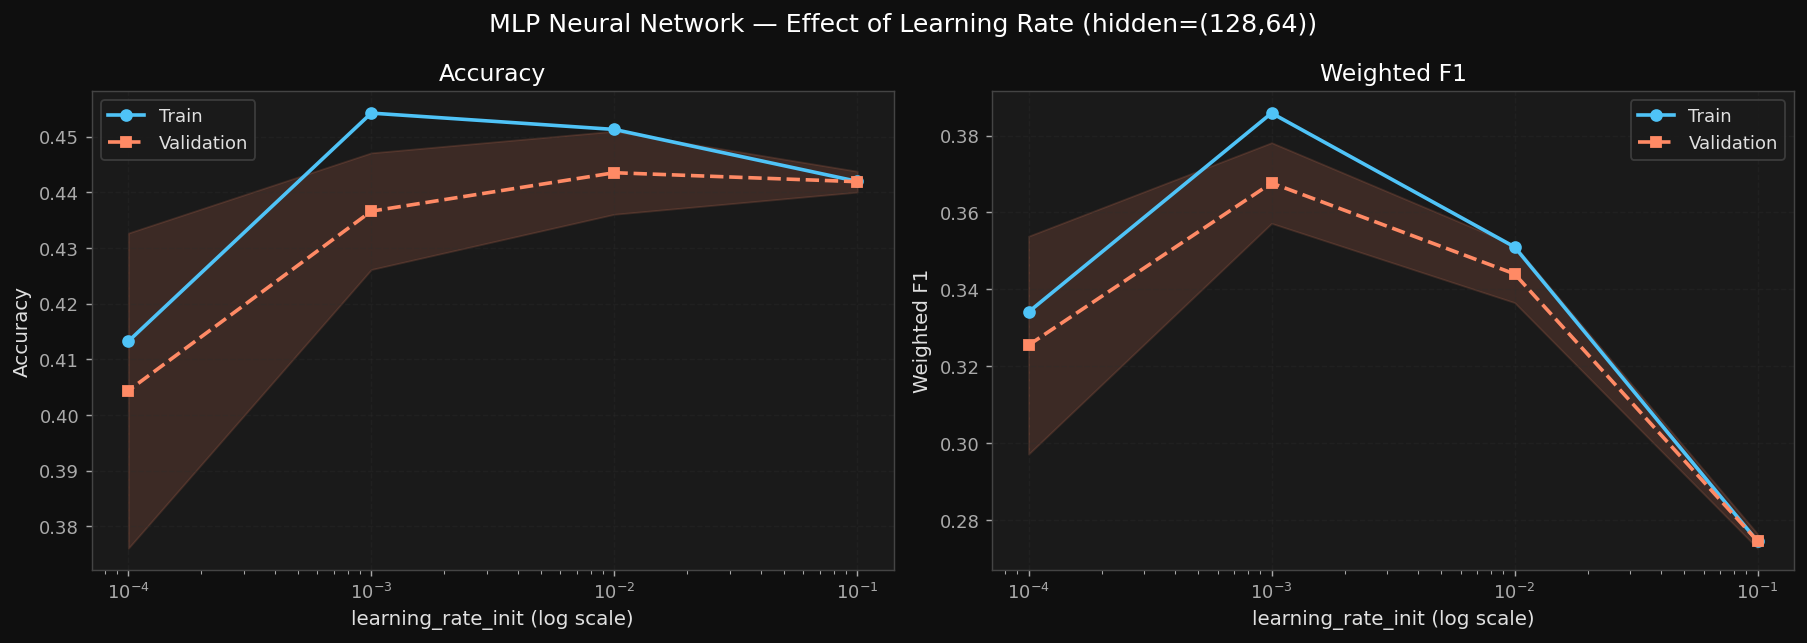


→ Best learning_rate: 0.001  (val_f1=0.3677)
→ Interpretation:
  lr=0.1 : likely oscillates — steps overshoot the loss minimum.
  lr=0.0001 : may underfit — 300 epochs insufficient to converge.
  Sweet spot: val F1 maximised, train-val gap minimised.


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP Neural Network — Effect of Learning Rate (hidden=(128,64))',
             fontsize=14, color='white')

for ax, (t_key, v_key, std_key), title in zip(axes,
    [('train_acc','val_acc','val_acc_std'), ('train_f1','val_f1','val_acc_std')],
    ['Accuracy', 'Weighted F1']):
    ax.semilogx(mlp_lr_df['lr'], mlp_lr_df[t_key], 'o-', color='#4fc3f7', label='Train', linewidth=2)
    ax.semilogx(mlp_lr_df['lr'], mlp_lr_df[v_key], 's--', color='#ff8a65', label='Validation', linewidth=2)
    ax.fill_between(mlp_lr_df['lr'],
                    mlp_lr_df[v_key] - mlp_lr_df[std_key],
                    mlp_lr_df[v_key] + mlp_lr_df[std_key],
                    alpha=0.15, color='#ff8a65')
    ax.set_xlabel('learning_rate_init (log scale)')
    ax.set_ylabel(title); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

best_lr_row = mlp_lr_df.loc[mlp_lr_df['val_f1'].idxmax()]
print(f"\n→ Best learning_rate: {best_lr_row['lr']}  (val_f1={best_lr_row['val_f1']:.4f})")
print("→ Interpretation:")
print("  lr=0.1 : likely oscillates — steps overshoot the loss minimum.")
print("  lr=0.0001 : may underfit — 300 epochs insufficient to converge.")
print("  Sweet spot: val F1 maximised, train-val gap minimised.")


In [89]:
best_lr = float(best_lr_row['lr'])
architectures = [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)]
mlp_arch_results = []

for arch in architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch, activation='relu', solver='adam',
        learning_rate_init=best_lr, max_iter=300,
        early_stopping=True, validation_fraction=0.1,
        random_state=42, alpha=1e-4)
    res = cross_validate(mlp, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=1)
    mlp_arch_results.append({
        'arch': str(arch),
        'params': sum(arch),
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  arch={str(arch):<16}  val_f1={res['test_f1'].mean():.4f}")

mlp_arch_df = pd.DataFrame(mlp_arch_results)


  arch=(64,)             val_f1=0.3886
  arch=(128,)            val_f1=0.3508
  arch=(64, 32)          val_f1=0.3599
  arch=(128, 64)         val_f1=0.3677
  arch=(128, 64, 32)     val_f1=0.3332


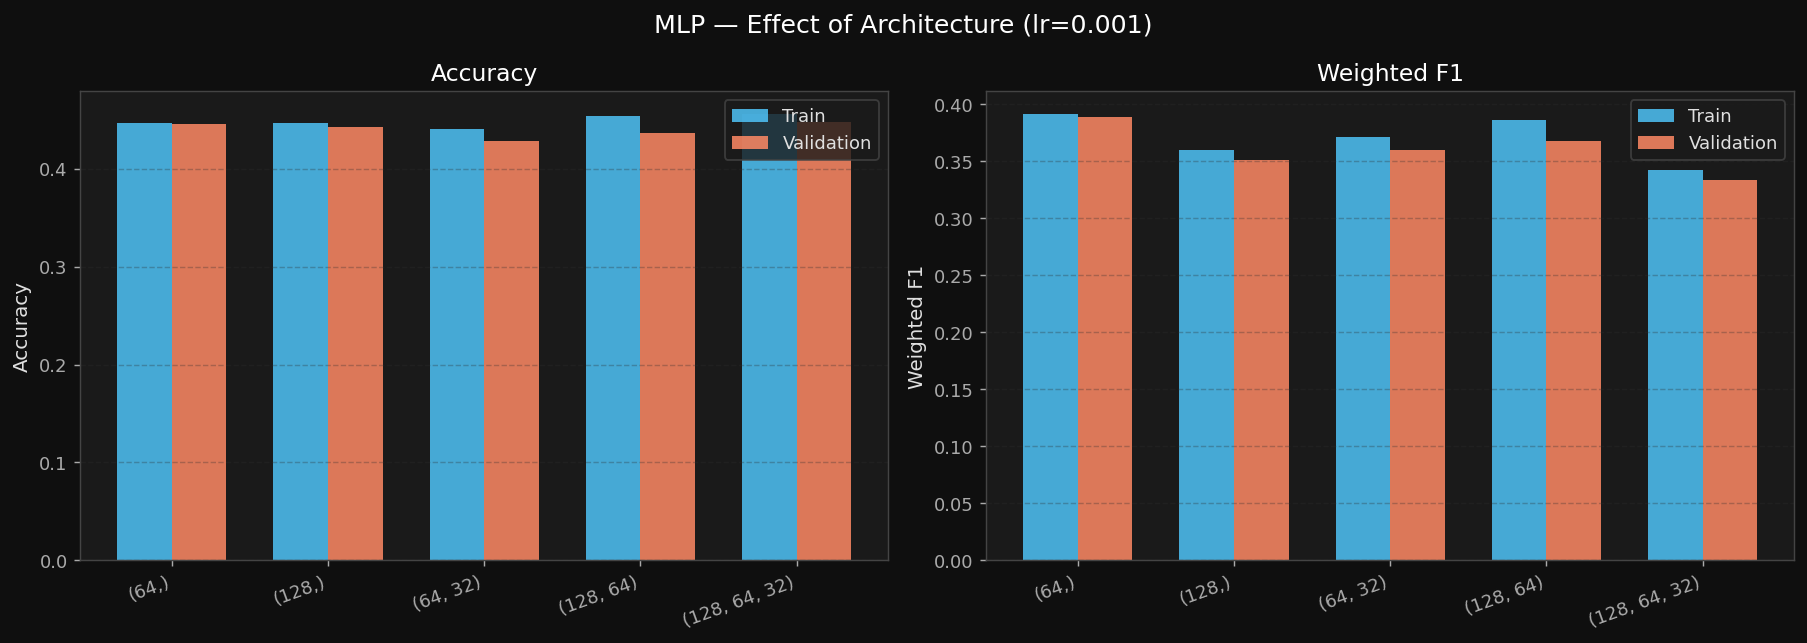

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'MLP — Effect of Architecture (lr={best_lr})', fontsize=14, color='white')
x_pos = range(len(mlp_arch_df))

for ax, (t_key, v_key), title in zip(axes,
    [('train_acc','val_acc'),('train_f1','val_f1')], ['Accuracy','Weighted F1']):
    width = 0.35
    ax.bar([p - width/2 for p in x_pos], mlp_arch_df[t_key], width, color='#4fc3f7', label='Train', alpha=0.85)
    ax.bar([p + width/2 for p in x_pos], mlp_arch_df[v_key], width, color='#ff8a65', label='Validation', alpha=0.85)
    ax.set_xticks(list(x_pos)); ax.set_xticklabels(mlp_arch_df['arch'], rotation=20, ha='right')
    ax.set_ylabel(title); ax.set_title(title)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


  alpha=1e-05     val_f1=0.3821
  alpha=0.0001    val_f1=0.3886
  alpha=0.001     val_f1=0.3841
  alpha=0.01      val_f1=0.3791
  alpha=0.1       val_f1=0.3804


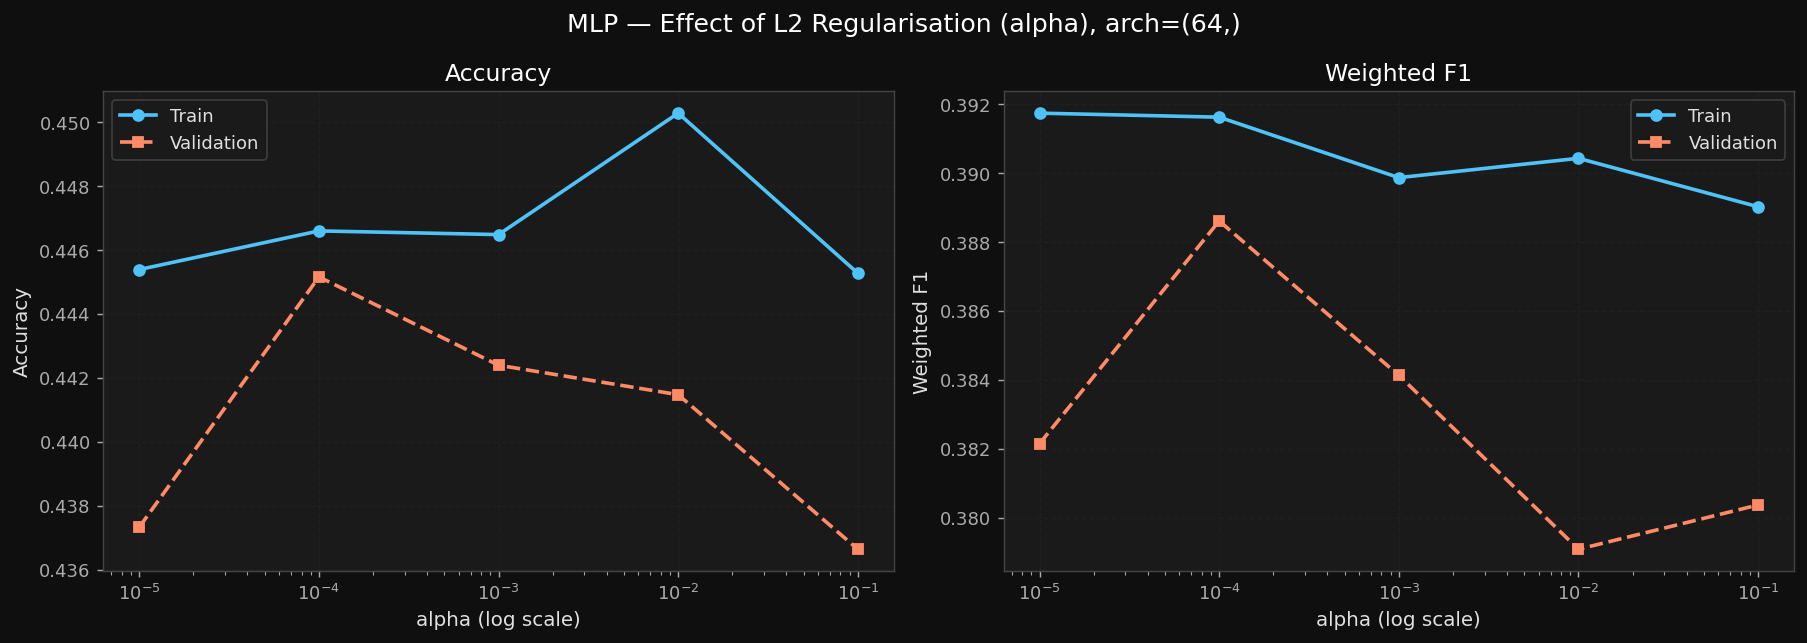

In [91]:
best_arch = eval(mlp_arch_df.loc[mlp_arch_df['val_f1'].idxmax(), 'arch'])
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
mlp_alpha_results = []

for a in alphas:
    mlp = MLPClassifier(
        hidden_layer_sizes=best_arch, activation='relu', solver='adam',
        learning_rate_init=best_lr, alpha=a, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=42)
    res = cross_validate(mlp, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=1)
    mlp_alpha_results.append({
        'alpha': a,
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  alpha={a:<8}  val_f1={res['test_f1'].mean():.4f}")

mlp_alpha_df = pd.DataFrame(mlp_alpha_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'MLP — Effect of L2 Regularisation (alpha), arch={best_arch}',
             fontsize=14, color='white')
for ax, (t_key, v_key), title in zip(axes,
    [('train_acc','val_acc'),('train_f1','val_f1')], ['Accuracy','Weighted F1']):
    ax.semilogx(mlp_alpha_df['alpha'], mlp_alpha_df[t_key], 'o-', color='#4fc3f7', label='Train', linewidth=2)
    ax.semilogx(mlp_alpha_df['alpha'], mlp_alpha_df[v_key], 's--', color='#ff8a65', label='Validation', linewidth=2)
    ax.set_xlabel('alpha (log scale)'); ax.set_ylabel(title); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [92]:
architectures = [(32,), (64,), (128,), (64, 32), (128, 64)]

mlp_arch_results = []

for arch in architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        alpha=1e-4
    )
    res = cross_validate(mlp, X, y, cv=cv,
                         scoring={'acc': 'accuracy', 'f1': 'f1_weighted'},
                         return_train_score=True, n_jobs=1)
    mlp_arch_results.append({
        'architecture': str(arch),
        'train_acc': res['train_acc'].mean(), 'val_acc': res['test_acc'].mean(),
        'train_f1':  res['train_f1'].mean(),  'val_f1':  res['test_f1'].mean(),
    })
    print(f"  arch={str(arch):<12}  val_f1={res['test_f1'].mean():.4f}  "
          f"train_f1={res['train_f1'].mean():.4f}  val_acc={res['test_acc'].mean():.4f}")

mlp_arch_df = pd.DataFrame(mlp_arch_results)
best_arch = mlp_arch_df.loc[mlp_arch_df['val_f1'].idxmax(), 'architecture']
print(f"\n→ Best architecture: {best_arch}")

  arch=(32,)         val_f1=0.3358  train_f1=0.3425  val_acc=0.4175
  arch=(64,)         val_f1=0.3886  train_f1=0.3916  val_acc=0.4452
  arch=(128,)        val_f1=0.3508  train_f1=0.3598  val_acc=0.4426
  arch=(64, 32)      val_f1=0.3599  train_f1=0.3707  val_acc=0.4288
  arch=(128, 64)     val_f1=0.3677  train_f1=0.3858  val_acc=0.4366

→ Best architecture: (64,)


In [86]:
best_mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    alpha=1e-4
)

In [95]:
import ast

# Convert best_arch from string to actual tuple if needed
if isinstance(best_arch, str):
    best_arch = ast.literal_eval(best_arch)

best_mlp = MLPClassifier(
    hidden_layer_sizes=best_arch,
    activation='relu', solver='adam',
    learning_rate_init=best_lr,
    max_iter=300, early_stopping=True,
    validation_fraction=0.1,
    random_state=42, alpha=1e-4
)
mlp_final = evaluate_model(best_mlp, X, y, cv,
                f"MLP (arch={best_arch}, lr={best_lr})")


──────────────────────────────────────────────────
  MLP (arch=(64,), lr=0.001)
──────────────────────────────────────────────────
  Train Accuracy : 0.4466 ± 0.0076
  Val   Accuracy : 0.4452 ± 0.0120
  Train F1 (wtd) : 0.3916 ± 0.0094
  Val   F1 (wtd) : 0.3886 ± 0.0178


In [96]:

best_svm = LinearSVC(C=best_C, class_weight='balanced', 
                     random_state=42, max_iter=2000)
svm_final = evaluate_model(best_svm, X, y, cv,
                f"SVM LinearSVC (C={best_C})")

best_mlp = MLPClassifier(
    hidden_layer_sizes=best_arch,
    activation='relu', solver='adam',
    learning_rate_init=best_lr,
    max_iter=300, early_stopping=True,
    validation_fraction=0.1,
    random_state=42, alpha=1e-4)
mlp_final = evaluate_model(best_mlp, X, y, cv,
                f"MLP (arch={best_arch}, lr={best_lr})")

model_comparison = pd.DataFrame([
    {
        'Model': f'Decision Tree\n(depth={best_depth_val}, min_split={best_ms})',
        'Val Accuracy': dt_final['test_accuracy'].mean(),
        'Val F1 (wtd)': dt_final['test_f1_weighted'].mean(),
        'Train Accuracy': dt_final['train_accuracy'].mean(),
        'Train F1 (wtd)': dt_final['train_f1_weighted'].mean(),
        'Val F1 Std': dt_final['test_f1_weighted'].std(),
    },
    {
        'Model': f'SVM LinearSVC\n(C={best_C})',
        'Val Accuracy': svm_final['test_accuracy'].mean(),
        'Val F1 (wtd)': svm_final['test_f1_weighted'].mean(),
        'Train Accuracy': svm_final['train_accuracy'].mean(),
        'Train F1 (wtd)': svm_final['train_f1_weighted'].mean(),
        'Val F1 Std': svm_final['test_f1_weighted'].std(),
    },
    {
        'Model': f'Random Forest\n(n={best_n}, depth={best_depth}, mss={best_mss})',
        'Val Accuracy': rf_final['test_accuracy'].mean(),
        'Val F1 (wtd)': rf_final['test_f1_weighted'].mean(),
        'Train Accuracy': rf_final['train_accuracy'].mean(),
        'Train F1 (wtd)': rf_final['train_f1_weighted'].mean(),
        'Val F1 Std': rf_final['test_f1_weighted'].std(),
    },
    {
        'Model': f'MLP\n(arch={best_arch}, lr={best_lr})',
        'Val Accuracy': mlp_final['test_accuracy'].mean(),
        'Val F1 (wtd)': mlp_final['test_f1_weighted'].mean(),
        'Train Accuracy': mlp_final['train_accuracy'].mean(),
        'Train F1 (wtd)': mlp_final['train_f1_weighted'].mean(),
        'Val F1 Std': mlp_final['test_f1_weighted'].std(),
    },
])

print(model_comparison[['Model','Train Accuracy','Val Accuracy',
                          'Train F1 (wtd)','Val F1 (wtd)',
                          'Val F1 Std']].to_string(index=False))


──────────────────────────────────────────────────
  SVM LinearSVC (C=0.001)
──────────────────────────────────────────────────
  Train Accuracy : 0.4203 ± 0.0065
  Val   Accuracy : 0.4014 ± 0.0102
  Train F1 (wtd) : 0.4088 ± 0.0070
  Val   F1 (wtd) : 0.3877 ± 0.0056

──────────────────────────────────────────────────
  MLP (arch=(64,), lr=0.001)
──────────────────────────────────────────────────
  Train Accuracy : 0.4466 ± 0.0076
  Val   Accuracy : 0.4452 ± 0.0120
  Train F1 (wtd) : 0.3916 ± 0.0094
  Val   F1 (wtd) : 0.3886 ± 0.0178
                                 Model  Train Accuracy  Val Accuracy  Train F1 (wtd)  Val F1 (wtd)  Val F1 Std
Decision Tree\n(depth=15, min_split=2)        1.000000      0.388479        1.000000      0.387684    0.017447
              SVM LinearSVC\n(C=0.001)        0.420276      0.401382        0.408772      0.387689    0.005557
Random Forest\n(n=50, depth=15, mss=5)        0.995680      0.453917        0.995683      0.438876    0.016323
           MLP\

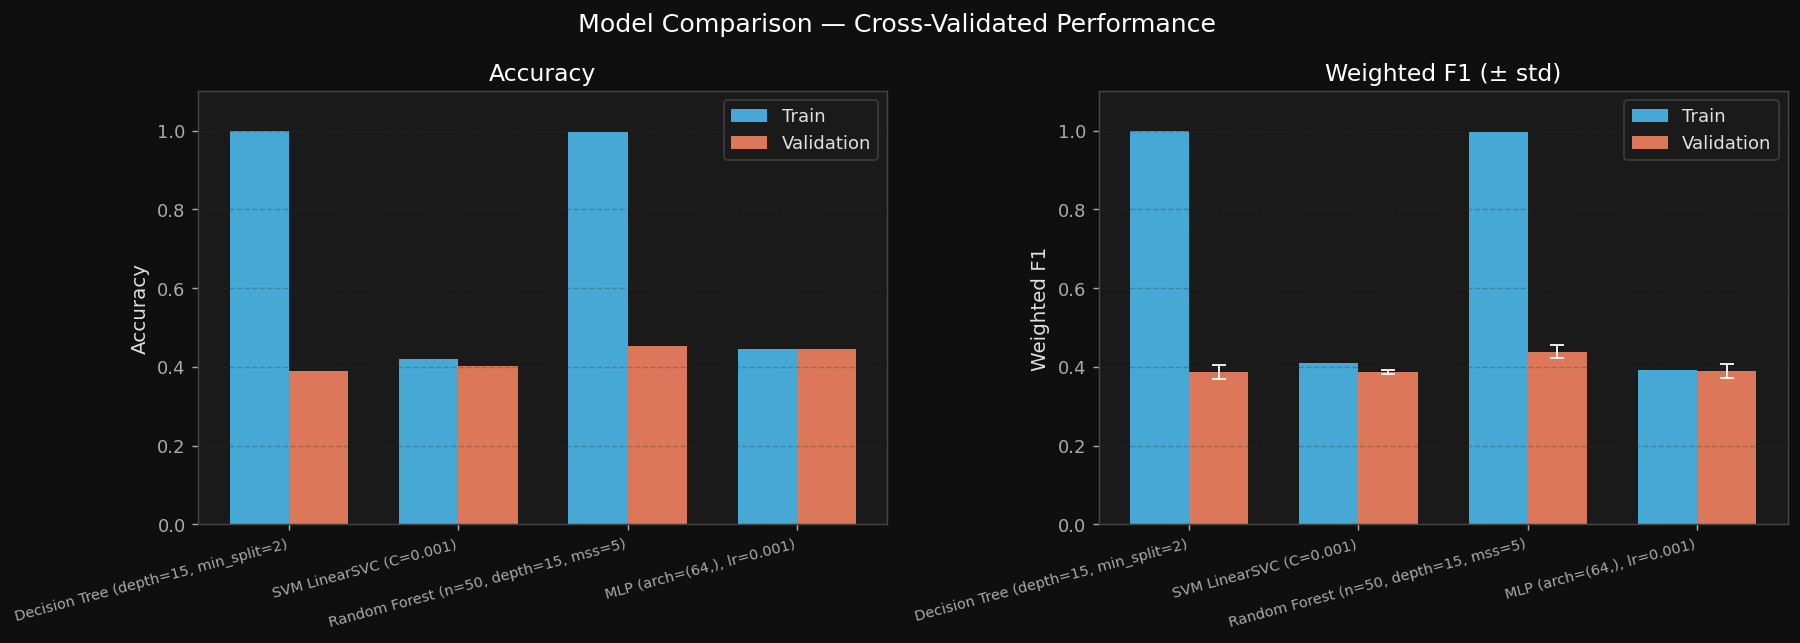

In [98]:
# ── 1. Visual Model Comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Cross-Validated Performance', fontsize=14, color='white')

models     = model_comparison['Model'].str.replace('\n', ' ')
val_f1     = model_comparison['Val F1 (wtd)']
train_f1   = model_comparison['Train F1 (wtd)']
val_acc    = model_comparison['Val Accuracy']
train_acc  = model_comparison['Train Accuracy']
val_f1_std = model_comparison['Val F1 Std']
x = np.arange(len(models))
w = 0.35

axes[0].bar(x - w/2, train_acc, w, color='#4fc3f7', label='Train', alpha=0.85)
axes[0].bar(x + w/2, val_acc,   w, color='#ff8a65', label='Validation', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('Accuracy'); axes[0].set_title('Accuracy')
axes[0].set_ylim(0, 1.1); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, train_f1, w, color='#4fc3f7', label='Train', alpha=0.85)
axes[1].bar(x + w/2, val_f1,   w, color='#ff8a65', label='Validation', alpha=0.85,
            yerr=val_f1_std, capsize=4, error_kw={'ecolor':'white','elinewidth':1})
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15, ha='right', fontsize=8)
axes[1].set_ylabel('Weighted F1'); axes[1].set_title('Weighted F1 (± std)')
axes[1].set_ylim(0, 1.1); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

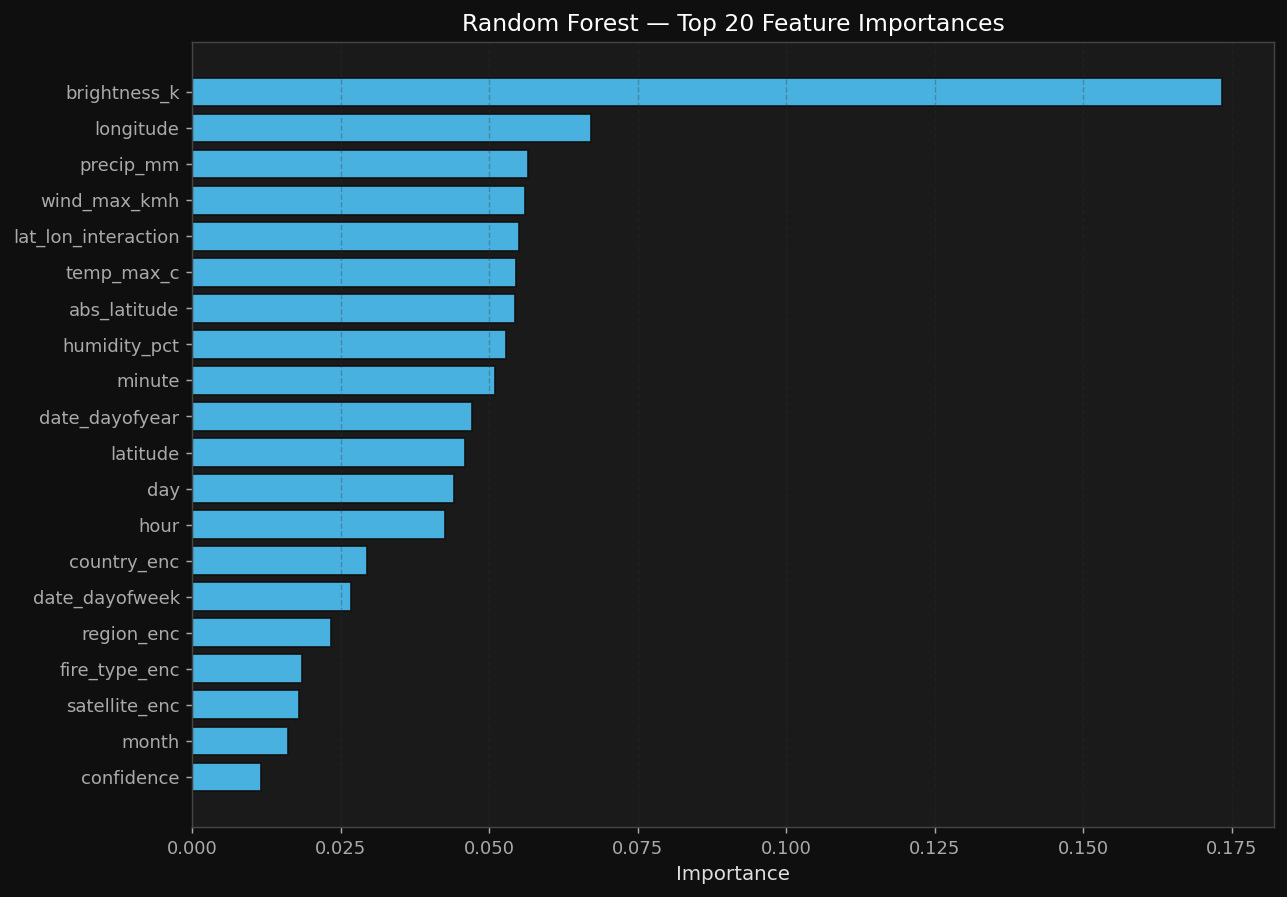


Top 10 features:
brightness_k           0.1735
longitude              0.0672
precip_mm              0.0566
wind_max_kmh           0.0561
lat_lon_interaction    0.0550
temp_max_c             0.0545
abs_latitude           0.0543
humidity_pct           0.0528
minute                 0.0509
date_dayofyear         0.0471


In [99]:
# ── 3. Random Forest Feature Importance ──
best_rf.fit(X, y)
importances = pd.Series(best_rf.feature_importances_, index=feat_cols).sort_values(ascending=True)
top_n = importances.tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_n.index, top_n.values, color='#4fc3f7', edgecolor='#111', alpha=0.9)
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=13)
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print("\nTop 10 features:")
print(importances.tail(10).sort_values(ascending=False).round(4).to_string())

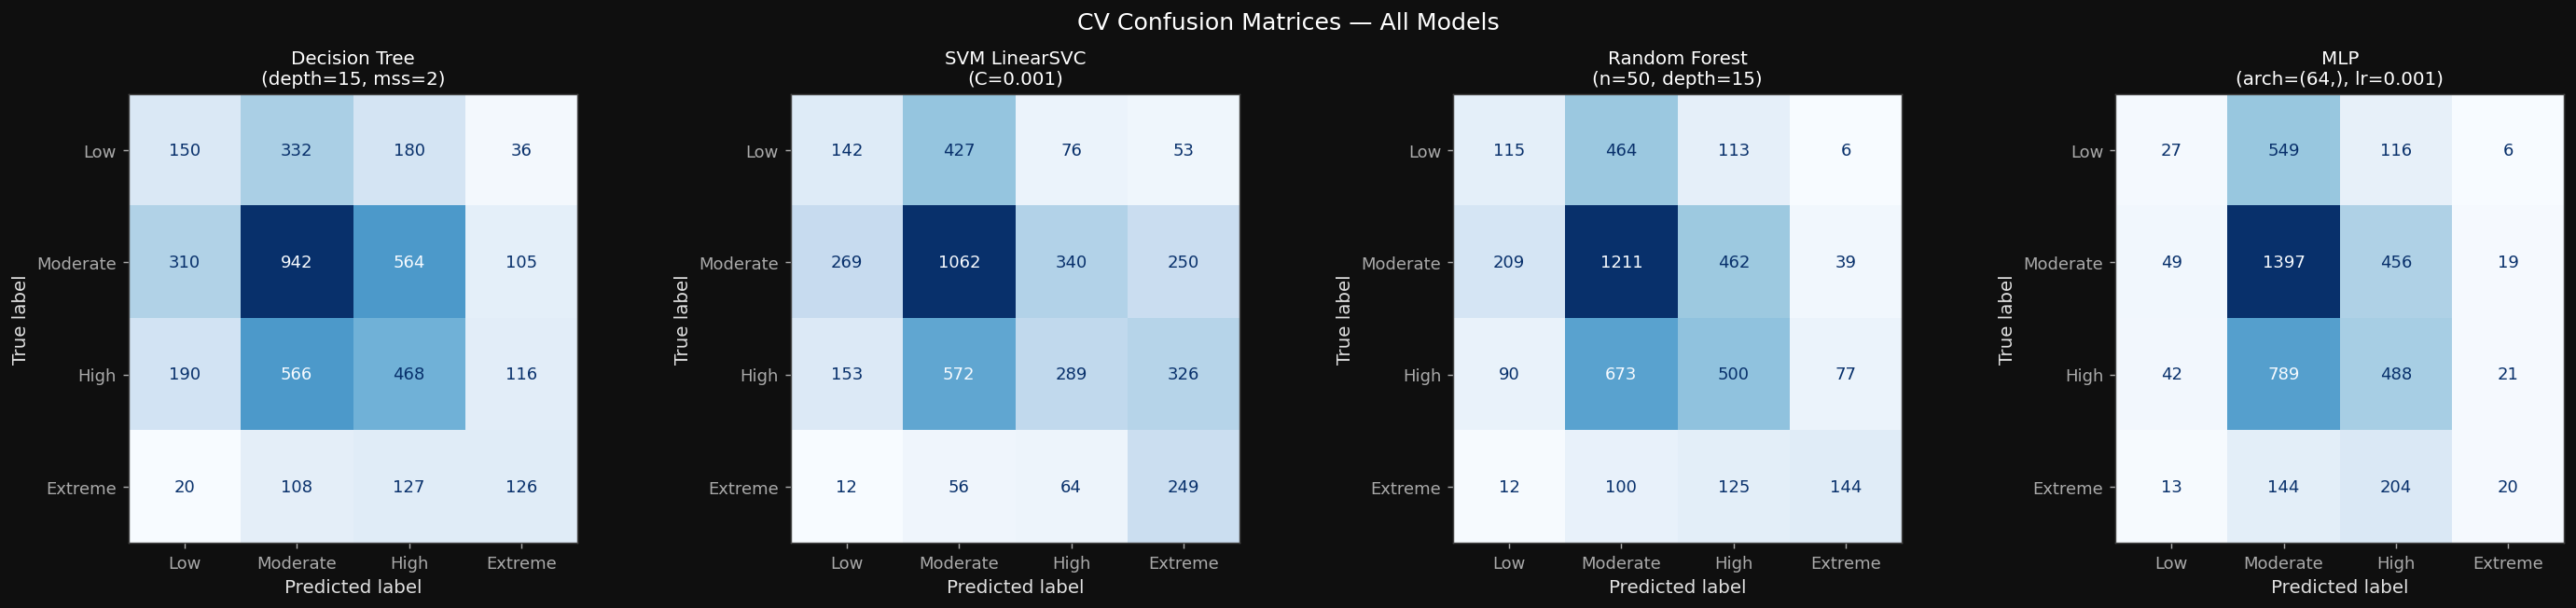

Exception ignored in: <function ResourceTracker.__del__ at 0x106cd1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1045d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x111a29bc0>
Traceback (most recent call last

In [ ]:
# ── 2. Confusion Matrices — All Models ──
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('CV Confusion Matrices — All Models', fontsize=14, color='white')

models_to_plot = [
    (best_dt,  f'Decision Tree\n(depth={best_depth_val}, mss={best_ms})'),
    (best_svm, f'SVM LinearSVC\n(C={best_C})'),
    (best_rf,  f'Random Forest\n(n={best_n}, depth={best_depth})'),
    (best_mlp, f'MLP\n(arch={best_arch}, lr={best_lr})'),
]

for ax, (model, title) in zip(axes, models_to_plot):
    plot_confusion(model, X, y, cv, title, ax)

plt.tight_layout(); plt.show()